# Alpha Vantage API : Top Favorite Company Stock Project
API Documentation: https://www.alphavantage.co/documentation/#intelligence

## Plan:

**To analyze and predict stock price returns of my favorite top 3 companies NVIDIA (NVDA), Apple (AAPL), and AMD using the closing prices as target variables for each respective stock.**

> **Closing Price:**
>  
> The closing price of a stock represents its price at the end of the trading day. 
> It is commonly used as the target variable in financial analysis and modeling because it reflects the final price at which a stock was traded during the day.  
>
> Predicting closing prices is a typical task in financial forecasting and analysis per my research.  

**For the project, i would like to set-up three separate models, each with the closing price of one of the stocks (NVDA, AAPL, and AMD) as the target variable. Then use historical data for the other columns (open, high, low, and volume) as features to train and evaluate models.**  
  
outline of pipeline process:  

### Data Acquisition:  
  
API call function to query data using documentation parameters to pull 20+ years of stock trade info for NVIDIA, APPLE INC., and AMD  
  
Acquire data and store in a pandas DataFrame.  
  
### Data Preparation:  
  
Clean and preprocess your dataset. Separate the data for NVDA, AAPL, and AMD.  
  
### Model Building:  
  
* Build separate predictive models for each stock (e.g., regression models, time series models, etc.).  
  
- **Use historical data for that stock's closing price as the target variable.**  
  
- **Use the other columns (open, high, low, and volume) as features to predict the closing price.**
  
### Training, Validation, and Testing:  
  
* Split the dataset into training, validation, and testing sets to evaluate model performance.  
  
* Train each model on historical data and evaluate its accuracy in predicting future closing prices.  
  
### Performance Metrics:   

Use appropriate performance metrics (e.g., Mean Absolute Error, Root Mean Squared Error, or others) to assess the accuracy of the models in predicting stock price returns.  
  
### Analysis and Insights:  
  
Analyze the results and insights gained from each model.  

Compare the performance of the models for different stocks.  

By setting up separate models for each stock and using closing prices as target variables, i could focus on analyzing and predicting stock price returns for NVIDIA, Apple, and AMD individually. This approach will allow me to tailor my analysis to the specific characteristics and behaviors of each stock.  

## Project Description:   
 
### **Analyzing my top 3 favorite companies to identify trends and behaviors and ultimately use features to predict the closing price.**

## Acquisition

In [1]:
# imported libraries
import requests
import pandas as pd
import numpy as np
import time
import os

# visual libs
import matplotlib.pyplot as plt
import seaborn as sns


# custom import to bring in api_key and not display
import config
import acquire as a
import prepare as p
import wrangle as w
import explore as e
import evaluate as ev
import model as m

In [2]:
api_key = config.ALPHA_VANTAGE_API_KEY

In [3]:
# per the alpha vantage api; documentation is well written and fairly easy to follow
# replace the "demo" apikey below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_MONTHLY&symbol=QQQ&apikey=api_key'
r = requests.get(url)
data = r.json()

print(data)

{'Meta Data': {'1. Information': 'Monthly Prices (open, high, low, close) and Volumes', '2. Symbol': 'QQQ', '3. Last Refreshed': '2023-10-04', '4. Time Zone': 'US/Eastern'}, 'Monthly Time Series': {'2023-10-04': {'1. open': '358.5400', '2. high': '362.6800', '3. low': '353.2750', '4. close': '359.7500', '5. volume': '166890229'}, '2023-09-29': {'1. open': '380.4000', '2. high': '380.8300', '3. low': '351.3600', '4. close': '358.2700', '5. volume': '960069773'}, '2023-08-31': {'1. open': '382.3100', '2. high': '383.5600', '3. low': '354.7100', '4. close': '377.9900', '5. volume': '1202809086'}, '2023-07-31': {'1. open': '370.0700', '2. high': '387.9800', '3. low': '363.4100', '4. close': '383.6800', '5. volume': '974887210'}, '2023-06-30': {'1. open': '347.7300', '2. high': '372.8500', '3. low': '346.6600', '4. close': '369.4200', '5. volume': '1138190013'}, '2023-05-31': {'1. open': '322.0900', '2. high': '353.9300', '3. low': '315.1150', '4. close': '347.9900', '5. volume': '114833799

### Decided to extract daily information from top diversified stock index funds

In [4]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=QQQ&outputsize=full&apikey=api_key'
r = requests.get(url)
data = r.json()

# Extract the daily time series data
daily_data = data['Time Series (Daily)']

# Convert the JSON data to a DataFrame
df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# Rename the columns
df = df.rename(columns={'1. open': 'qqq_open', '2. high': 'qqq_high', '3. low': 'qqq_low', '4. close': 'qqq_close', '5. volume': 'qqq_volume'})

# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# checking info of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6020 entries, 2023-10-04 to 1999-11-01
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   qqq_open    6020 non-null   object
 1   qqq_high    6020 non-null   object
 2   qqq_low     6020 non-null   object
 3   qqq_close   6020 non-null   object
 4   qqq_volume  6020 non-null   object
dtypes: object(5)
memory usage: 282.2+ KB


### Noted all data returned when queried comes back as a object

In [5]:
df.head()

,qqq_open,qqq_high,qqq_low,qqq_close,qqq_volume
2023-10-04,355.7700,360.6100,355.3000,359.7500,54786686
2023-10-03,358.7800,361.0100,353.2750,354.9200,60478489
2023-10-02,358.5400,362.6800,357.9200,361.2600,51625054
2023-09-29,361.5400,362.9500,357.0200,358.2700,64829616
2023-09-28,354.1100,360.1700,353.2400,358.0100,56453312


In [6]:
df.index.dtype

dtype('<M8[ns]')

In [7]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=DIA&outputsize=full&apikey=api_key'
r = requests.get(url)
data = r.json()

# Extract the daily time series data
daily_data = data['Time Series (Daily)']

# Convert the JSON data to a DataFrame
df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# Rename the columns
df = df.rename(columns={'1. open': 'dia_open', '2. high': 'dia_high', '3. low': 'dia_low', '4. close': 'dia_close', '5. volume': 'dia_volume'})

# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# Print the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6020 entries, 2023-10-04 to 1999-11-01
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   dia_open    6020 non-null   object
 1   dia_high    6020 non-null   object
 2   dia_low     6020 non-null   object
 3   dia_close   6020 non-null   object
 4   dia_volume  6020 non-null   object
dtypes: object(5)
memory usage: 282.2+ KB


In [8]:
df.head()

,dia_open,dia_high,dia_low,dia_close,dia_volume
2023-10-04,330.1300,331.4600,328.6050,330.9900,4877148
2023-10-03,332.8400,333.8800,329.0401,329.9800,4871058
2023-10-02,334.2900,335.0200,332.0800,334.0900,4192554
2023-09-29,338.7800,338.8300,333.9100,334.9500,3786535
2023-09-28,335.3200,337.6700,334.5700,336.6200,4053596


In [9]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=SPY&outputsize=full&apikey=api_key'
r = requests.get(url)
data = r.json()

# Extract the daily time series data
daily_data = data['Time Series (Daily)']

# Convert the JSON data to a DataFrame
df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# Rename the columns
df = df.rename(columns={'1. open': 'spy_open', '2. high': 'spy_high', '3. low': 'spy_low', '4. close': 'spy_close', '5. volume': 'spy_volume'})

# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# Print the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6020 entries, 2023-10-04 to 1999-11-01
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   spy_open    6020 non-null   object
 1   spy_high    6020 non-null   object
 2   spy_low     6020 non-null   object
 3   spy_close   6020 non-null   object
 4   spy_volume  6020 non-null   object
dtypes: object(5)
memory usage: 282.2+ KB


In [10]:
df.head()

,spy_open,spy_high,spy_low,spy_close,spy_volume
2023-10-04,422.0700,425.4299,420.5600,424.6600,87452968
2023-10-03,425.0600,427.3729,420.1800,421.5900,103760607
2023-10-02,426.6200,428.6000,424.4600,427.3100,83798599
2023-09-29,431.6700,431.8500,425.9100,427.4800,115111319
2023-09-28,425.4800,430.2499,424.8700,428.5200,92258308


In [11]:

# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&outputsize=full&apikey=demo

# Sample ticker traded in UK - London Stock Exchange
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=TSCO.LON&outputsize=full&apikey=demo

# Sample ticker traded in Canada - Toronto Stock Exchange
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=SHOP.TRT&outputsize=full&apikey=demo

# Sample ticker traded in Canada - Toronto Venture Exchange
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=GPV.TRV&outputsize=full&apikey=demo

# Sample ticker traded in Germany - XETRA
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=MBG.DEX&outputsize=full&apikey=demo

# Sample ticker traded in India - BSE
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=RELIANCE.BSE&outputsize=full&apikey=demo

# Sample ticker traded in China - Shanghai Stock Exchange
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=600104.SHH&outputsize=full&apikey=demo

# Sample ticker traded in China - Shenzhen Stock Exchange
# https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=000002.SHZ&outputsize=full&apikey=demo

### I can see all efts, stocks, etc. are all organized from 1999 to current date so i should be able to just input stock symbols for company I would like to query with the same time frames.

* favorite companies  

Nvidia Corporation: The stock symbol for Nvidia is NVDA.
    
Apple Inc.: The stock symbol for Apple is AAPL.    

Advanced Micro Devices, Inc. (AMD): The stock symbol for AMD is AMD

* oversea stocks

iShares China Large-Cap ETF: FXI  

Shares MSCI India ETF: INDA  

iShares MSCI United Kingdom ETF: EWU

## Above were some ideas scanned and interested in

### I am checking each of my favorite companies data to see if they would all have similar date range of records

In [12]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=NVDA&outputsize=full&apikey=api_key'
r = requests.get(url)
data = r.json()

# Extract the daily time series data
daily_data = data['Time Series (Daily)']

# Convert the JSON data to a DataFrame
df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# Rename the columns
df = df.rename(columns={'1. open': 'nvda_open', '2. high': 'nvda_high', '3. low': 'nvda_low', '4. close': 'nvda_close', '5. volume': 'nvda_volume'})

# Convert the index to datetime
df.index = pd.to_datetime(df.index)

# checking info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6020 entries, 2023-10-04 to 1999-11-01
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nvda_open    6020 non-null   object
 1   nvda_high    6020 non-null   object
 2   nvda_low     6020 non-null   object
 3   nvda_close   6020 non-null   object
 4   nvda_volume  6020 non-null   object
dtypes: object(5)
memory usage: 282.2+ KB


In [13]:
df.head()

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume
2023-10-04,437.4200,441.4300,432.9201,440.4100,36182086
2023-10-03,448.0800,451.3000,432.4600,435.1700,47084954
2023-10-02,440.3000,451.7500,438.6100,447.8200,43329821
2023-09-29,438.2700,441.4400,433.0694,434.9900,39782993
2023-09-28,424.6000,434.4631,421.1500,430.8900,42466279


In [15]:
# # Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
# url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=AAPL&outputsize=full&apikey=api_key'
# r = requests.get(url)
# data = r.json()

# # Extract the daily time series data
# daily_data = data['Time Series (Daily)']

# # Convert the JSON data to a DataFrame
# df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# # Rename the columns
# df = df.rename(columns={'1. open': 'aapl_open', '2. high': 'aapl_high', '3. low': 'aapl_low', '4. close': 'aapl_close', '5. volume': 'aapl_volume'})

# # Convert the index to datetime
# df.index = pd.to_datetime(df.index)

# # Print the DataFrame info
# df.info()

In [16]:
df.head()

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume
2023-10-04,437.4200,441.4300,432.9201,440.4100,36182086
2023-10-03,448.0800,451.3000,432.4600,435.1700,47084954
2023-10-02,440.3000,451.7500,438.6100,447.8200,43329821
2023-09-29,438.2700,441.4400,433.0694,434.9900,39782993
2023-09-28,424.6000,434.4631,421.1500,430.8900,42466279


In [18]:
# Replace the "demo" API key below with your own key from https://www.alphavantage.co/support/#api-key
# url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=AMD&outputsize=full&apikey=api_key'
# r = requests.get(url)
# data = r.json()

# # Extract the daily time series data
# daily_data = data['Time Series (Daily)']

# # Convert the JSON data to a DataFrame
# df = pd.DataFrame(daily_data).T  # Transpose to have dates as index

# # Rename the columns
# df = df.rename(columns={'1. open': 'amd_open', '2. high': 'amd_high', '3. low': 'amd_low', '4. close': 'amd_close', '5. volume': 'amd_volume'})

# # Convert the index to datetime
# df.index = pd.to_datetime(df.index)

# # Print the DataFrame info
# df.info()

  ## Fortunately all the data was organized well and the follwiong code block is a function that uses recommended syntax. The url has been adjusted to retuen all listed symbols specified and then return all df for the stock data concatenated.

In [20]:
# # Function to retrieve and process data for a stock symbol
# def get_stock_data(symbol, api_key):
#     url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&outputsize=full&apikey={api_key}'
#     r = requests.get(url)
#     data = r.json()
    
#     daily_data = data['Time Series (Daily)']
    
#     df = pd.DataFrame(daily_data).T  # Transpose to have dates as index
#     df = df.rename(columns={'1. open': f'{symbol}_open', '2. high': f'{symbol}_high', '3. low': f'{symbol}_low', '4. close': f'{symbol}_close', '5. volume': f'{symbol}_volume'})
#     df.index = pd.to_datetime(df.index) # set the index for timestamps to dattime values; originally object.
    
#     return df

# # Get data for NVDA, AAPL, and AMD
# nvda_data = get_stock_data('NVDA', api_key)
# aapl_data = get_stock_data('AAPL', api_key)
# amd_data = get_stock_data('AMD', api_key)

# # Concatenate the dataframes into a single dataframe
# all_data = pd.concat([nvda_data, aapl_data, amd_data], axis=1)

# # Print the concatenated dataframe
# all_data.head()

In [22]:
# df = all_data

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6020 entries, 2023-10-04 to 1999-11-01
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nvda_open    6020 non-null   object
 1   nvda_high    6020 non-null   object
 2   nvda_low     6020 non-null   object
 3   nvda_close   6020 non-null   object
 4   nvda_volume  6020 non-null   object
dtypes: object(5)
memory usage: 282.2+ KB


## Now that i have combined my data I can review the information and clean the dataset for ease of use

## below are some other functions i was going to implement, but decided to use my favorite companies

In [24]:
# # Function to retrieve and process data for a stock symbol
# def get_diversified_stock_index_funds_data(symbol, api_key):
#     url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&outputsize=full&apikey={api_key}'
#     r = requests.get(url)
#     data = r.json()
    
#     daily_data = data['Time Series (Daily)'] 
    
#     df = pd.DataFrame(daily_data).T  # Transpose to have dates as index
#     df = df.rename(columns={'1. open': f'{symbol}_open', '2. high': f'{symbol}_high', '3. low': f'{symbol}_low', '4. close': f'{symbol}_close', '5. volume': f'{symbol}_volume'})
#     df.index = pd.to_datetime(df.index)
    
#     return df

# # Get data for SPY, DIA, and QQQ
# spy_data = get_stock_data('SPY', api_key)
# dia_data = get_stock_data('DIA', api_key)
# qqq_data = get_stock_data('QQQ', api_key)

# # Concatenate the dataframes into a single dataframe
# dsif_data = pd.concat([spy_data, dia_data, qqq_data], axis=1)

# # Print the concatenated dataframe
# dsif_data.head()

In [25]:
# import requests
# import pandas as pd

# # Function to retrieve and process data for an ETF symbol
# def get_etf_data(symbol, api_key):
#     url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&outputsize=full&apikey={api_key}'
#     r = requests.get(url)
#     data = r.json()
    
#     daily_data = data['Time Series (Daily)'] 
    
#     df = pd.DataFrame(daily_data).T  # Transpose to have dates as index
#     df = df.rename(columns={'1. open': f'{symbol}_open', '2. high': f'{symbol}_high', '3. low': f'{symbol}_low', '4. close': f'{symbol}_close', '5. volume': f'{symbol}_volume'})
#     df.index = pd.to_datetime(df.index)
    
#     return df

# # Replace "YOUR_API_KEY" with your actual API key
# api_key = 'CDJ0WTJ22LPVEIXL'

# # Get data for FXI, INDA, and EWU
# mchi_data = get_etf_data('MCHI', api_key)
# inda_data = get_etf_data('INDA', api_key)
# midd_data = get_etf_data('MIDD', api_key)

# # Concatenate the dataframes into a single dataframe
# all_etf_data = pd.concat([mchi_data, inda_data, midd_data], axis=1)

# # Print the concatenated dataframe
# all_etf_data.head()

# Prepare   
  

## I need to convert the data into float/int values  

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6020 entries, 2023-10-04 to 1999-11-01
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nvda_open    6020 non-null   object
 1   nvda_high    6020 non-null   object
 2   nvda_low     6020 non-null   object
 3   nvda_close   6020 non-null   object
 4   nvda_volume  6020 non-null   object
dtypes: object(5)
memory usage: 282.2+ KB


## As previously inspected; there is no null values and counts match up below as well

In [27]:
df.describe().T

,count,unique,top,freq
nvda_open,6020,4274,22.0000,9
nvda_high,6020,4347,36.7500,12
nvda_low,6020,4379,14.3800,10
nvda_close,6020,4491,12.2600,7
nvda_volume,6020,5990,3093600,2


In [28]:
df = df.apply(pd.to_numeric)

In [29]:
# all columns are now numeric volume
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6020 entries, 2023-10-04 to 1999-11-01
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nvda_open    6020 non-null   float64
 1   nvda_high    6020 non-null   float64
 2   nvda_low     6020 non-null   float64
 3   nvda_close   6020 non-null   float64
 4   nvda_volume  6020 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 282.2 KB


## I read that volume should be an integer and turning into a float presents no advantage to analysis of data

## Our dataset is comprised of 6,019 observations and 15 columns

In [30]:
df.shape

(6020, 5)

## Here I decided to make the column names lowercase and add underscores to make the data column names more pythonic.

In [31]:
# cleaned up columns names
df.columns = [col.lower() for col in df.columns]
df.head()

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume
2023-10-04,437.42,441.4300,432.9201,440.41,36182086
2023-10-03,448.08,451.3000,432.4600,435.17,47084954
2023-10-02,440.30,451.7500,438.6100,447.82,43329821
2023-09-29,438.27,441.4400,433.0694,434.99,39782993
2023-09-28,424.60,434.4631,421.1500,430.89,42466279


In [32]:
# returning date range of data
print('Date Range:', df.index.min(), 'to', df.index.max())
print('Shape:', df.shape)

Date Range: 1999-11-01 00:00:00 to 2023-10-04 00:00:00
Shape: (6020, 5)


## after checking the date range to ensure my data had a time range usable for analysis, I now am going to view at the distribution of the data retrieved.

In [34]:
# # Select a subset of columns for visualization
# selected_columns = ['nvda_open', 'aapl_open', 'amd_open',
#                     'nvda_high', 'aapl_high', 'amd_high',
#                     'nvda_low', 'aapl_low', 'amd_low',
#                     'nvda_close', 'aapl_close', 'amd_close',
#                     'nvda_volume', 'aapl_volume', 'amd_volume',]

# # Create subplots for each column
# fig, axes = plt.subplots(nrows=len(selected_columns), figsize=(6, 40))

# for i, column in enumerate(selected_columns):
#     axes[i].hist(df[column], bins=25)  # You can adjust the number of bins as needed
#     axes[i].set_title(f'Data Distribution for {column}')
#     axes[i].set_xlabel(column)
#     axes[i].set_ylabel('Count')

# plt.tight_layout()
# plt.show()


## After viewing the data using visualization tools and binning the data to see a clearer distribution. I can determine that the data has a normal distribution.

# Explore

## I will now create categorical columns for exploration (day_of_week, month)

In [35]:
df['month'] = df.index.month_name()
df['day_of_week'] = df.index.day_name()

In [36]:
df.head()

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume,month,day_of_week
2023-10-04,437.42,441.4300,432.9201,440.41,36182086,October,Wednesday
2023-10-03,448.08,451.3000,432.4600,435.17,47084954,October,Tuesday
2023-10-02,440.30,451.7500,438.6100,447.82,43329821,October,Monday
2023-09-29,438.27,441.4400,433.0694,434.99,39782993,September,Friday
2023-09-28,424.60,434.4631,421.1500,430.89,42466279,September,Thursday


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6020 entries, 2023-10-04 to 1999-11-01
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nvda_open    6020 non-null   float64
 1   nvda_high    6020 non-null   float64
 2   nvda_low     6020 non-null   float64
 3   nvda_close   6020 non-null   float64
 4   nvda_volume  6020 non-null   int64  
 5   month        6020 non-null   object 
 6   day_of_week  6020 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 376.2+ KB


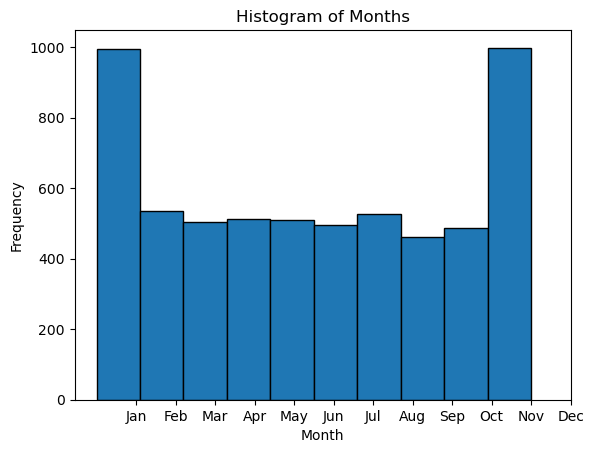

In [38]:
plt.hist(df['month'], ec='black')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Histogram of Months')

# Define custom labels for the ticks
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Set the custom labels for the x-axis ticks
plt.xticks(range(1, 13), month_labels)

plt.show()

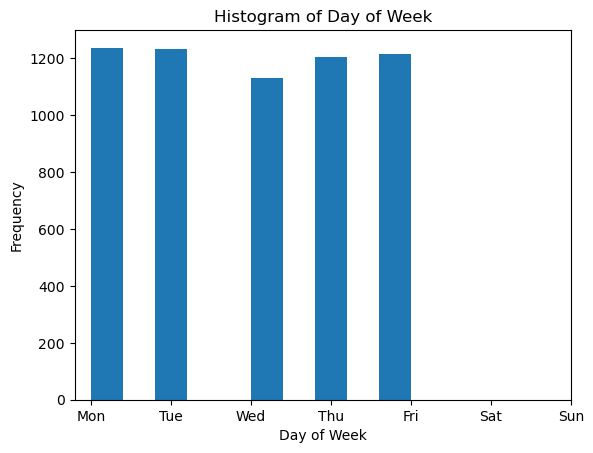

In [39]:
plt.hist(df['day_of_week'])
plt.xlabel('Day of Week')
plt.ylabel('Frequency')
plt.title('Histogram of Day of Week')

# Define custom labels for the ticks
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Set the custom labels for the x-axis ticks
plt.xticks(range(7), day_labels)

plt.show()

## My categorical data displays a higher frequency for stocks active during the week highlighting closed market on the weekends. Also months nov-dec seem to have no activity?

## now i'm going to look at the data of the stock company I selected from

In [42]:
# sns.scatterplot(data = amd_df, x='amd_open', y='amd_volume', hue='month')
# plt.title('Open versus volume (amd)')

In [43]:
# sns.scatterplot(data = df, x='nvda_open', y='nvda_volume', hue='month')
# plt.title('Open versus volume (NVIDIA)')

In [44]:
# sns.scatterplot(data = df, x='aapl_open', y='aapl_volume', hue='month')
# plt.title('Open versus volume (apple)')

## The scatter plots here are very interesting to look at, here we can see comparisons and how these feature are displayed

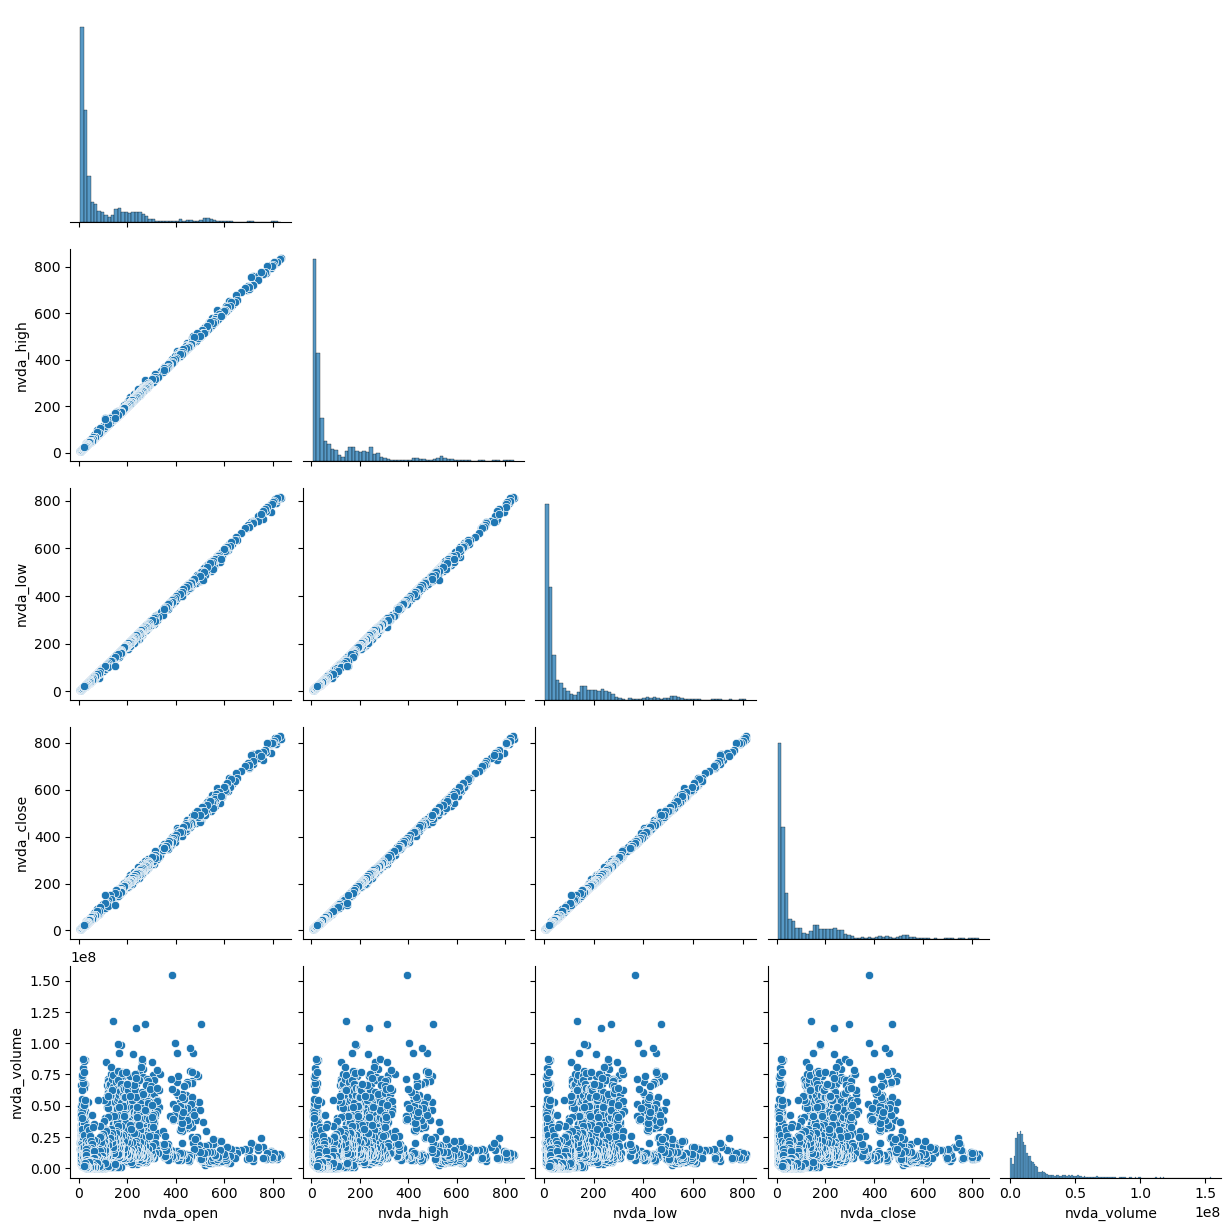

In [45]:
sns.pairplot(df, corner=True)

## I can see all these grouped data have skewed plots with no apparent correlation so i need to split each and look at the individually.

## Now i am going to seperate each set by calling get_stock_function and then clean with my prep function

In [46]:
# Get data for NVDA, AAPL, AMD, TSLA, and VVOS
nvda_data = a.get_stock_data('NVDA', api_key)
aapl_data = a.get_stock_data('AAPL', api_key)
amd_data = a.get_stock_data('AMD', api_key)
tsla_data = a.get_stock_data('TSLA', api_key)
vvos_data = a.get_stock_data('VVOS', api_key)

In [47]:
nvda_data.shape

(37, 5)

In [48]:
nvda_data.head()

,NVDA_open,NVDA_high,NVDA_low,NVDA_close,NVDA_volume
2023-10-04,440.300,451.75,432.46,440.41,126596861
2023-09-29,497.620,498.00,409.80,434.99,858010319
2023-08-31,464.595,502.66,403.11,493.55,1363638357
2023-07-31,425.170,480.88,413.46,467.29,870901174
2023-06-30,384.890,439.90,373.56,423.02,1052802408


In [49]:
aapl_data.head()

,AAPL_open,AAPL_high,AAPL_low,AAPL_close,AAPL_volume
2023-10-04,171.220,174.30,170.8200,173.66,154779434
2023-09-29,189.485,189.98,167.6200,171.21,1337873796
2023-08-31,196.235,196.73,171.9600,187.87,1323817340
2023-07-31,193.780,198.23,186.6000,196.45,996368613
2023-06-30,177.700,194.48,176.9306,193.97,1297863403


In [50]:
amd_data.head()

,AMD_open,AMD_high,AMD_low,AMD_close,AMD_volume
2023-10-04,102.21,104.40,99.17,104.07,144258800
2023-09-29,107.00,111.82,94.46,102.82,1044530220
2023-08-31,114.26,119.50,99.58,105.72,1573690096
2023-07-31,115.16,122.12,108.55,114.40,1142100773
2023-06-30,117.29,132.83,107.08,113.91,1543262982


In [51]:
tsla_data.head()

,TSLA_open,TSLA_high,TSLA_low,TSLA_close,TSLA_volume
2023-10-04,244.81,261.86,242.62,261.16,355517274
2023-09-29,257.26,278.98,234.58,250.22,2440633653
2023-08-31,266.26,266.47,212.36,258.08,2503253508
2023-07-31,276.49,299.29,254.12,267.43,2394275082
2023-06-30,202.59,276.99,199.37,261.77,3443091887


In [52]:
vvos_data.head()

,VVOS_open,VVOS_high,VVOS_low,VVOS_close,VVOS_volume
2023-10-04,0.1910,0.4498,0.1801,0.3045,251500408
2023-09-29,0.2501,0.2748,0.1800,0.1921,3525115
2023-08-31,0.3000,0.5606,0.2403,0.2513,87295797
2023-07-31,0.4876,0.5431,0.2303,0.2910,8377881
2023-06-30,0.4200,0.5602,0.3900,0.5100,4111486


In [53]:
def prep(df):
    '''
    prepare function used to take pass specific stock company dataframe and clean the information as well as createa couple features
    '''
    
    df = df.apply(pd.to_numeric)
    df.columns = [col.lower() for col in df.columns]
    df['month'] = df.index.month_name()
    df['day_of_week'] = df.index.day_name()
    
    return df

In [54]:
nvda_df = p.prep(nvda_data, 'NVDA', 'cleaned_data')
aapl_df = p.prep(aapl_data, 'AAPL', 'cleaned_data')
amd_df = p.prep(amd_data, 'AMD', 'cleaned_data')
tsla_df = p.prep(tsla_data, 'TSLA', 'cleaned_data')

In [55]:
nvda_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 37 entries, 2023-10-04 to 2020-10-30
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nvda_open    37 non-null     float64
 1   nvda_high    37 non-null     float64
 2   nvda_low     37 non-null     float64
 3   nvda_close   37 non-null     float64
 4   nvda_volume  37 non-null     int64  
 5   month        37 non-null     object 
 6   day_of_week  37 non-null     object 
 7   year         37 non-null     int32  
dtypes: float64(4), int32(1), int64(1), object(2)
memory usage: 2.5+ KB


## After accomplishing this task I am going to RE-explore teh data ditribution for each and pair plot to see if i can find any insightful information between all feature of each company stock.

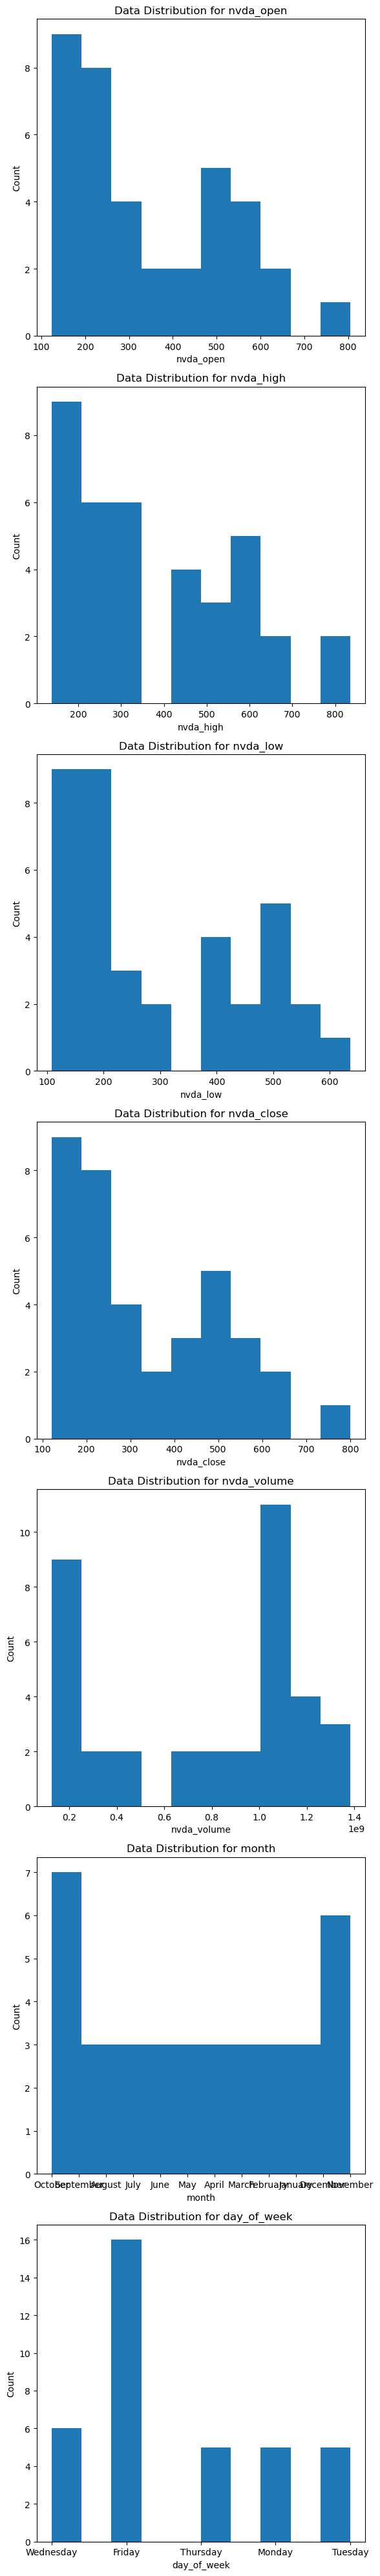

In [56]:
# Select a subset of columns for visualization
selected_columns = ['nvda_open','nvda_high','nvda_low',
                    'nvda_close', 'nvda_volume', 'month',
                    'day_of_week']

# Create subplots for each column
fig, axes = plt.subplots(nrows=len(selected_columns), figsize=(6, 40))

for i, column in enumerate(selected_columns):
    axes[i].hist(nvda_df[column])  # You can adjust the number of bins as needed
    axes[i].set_title(f'Data Distribution for {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

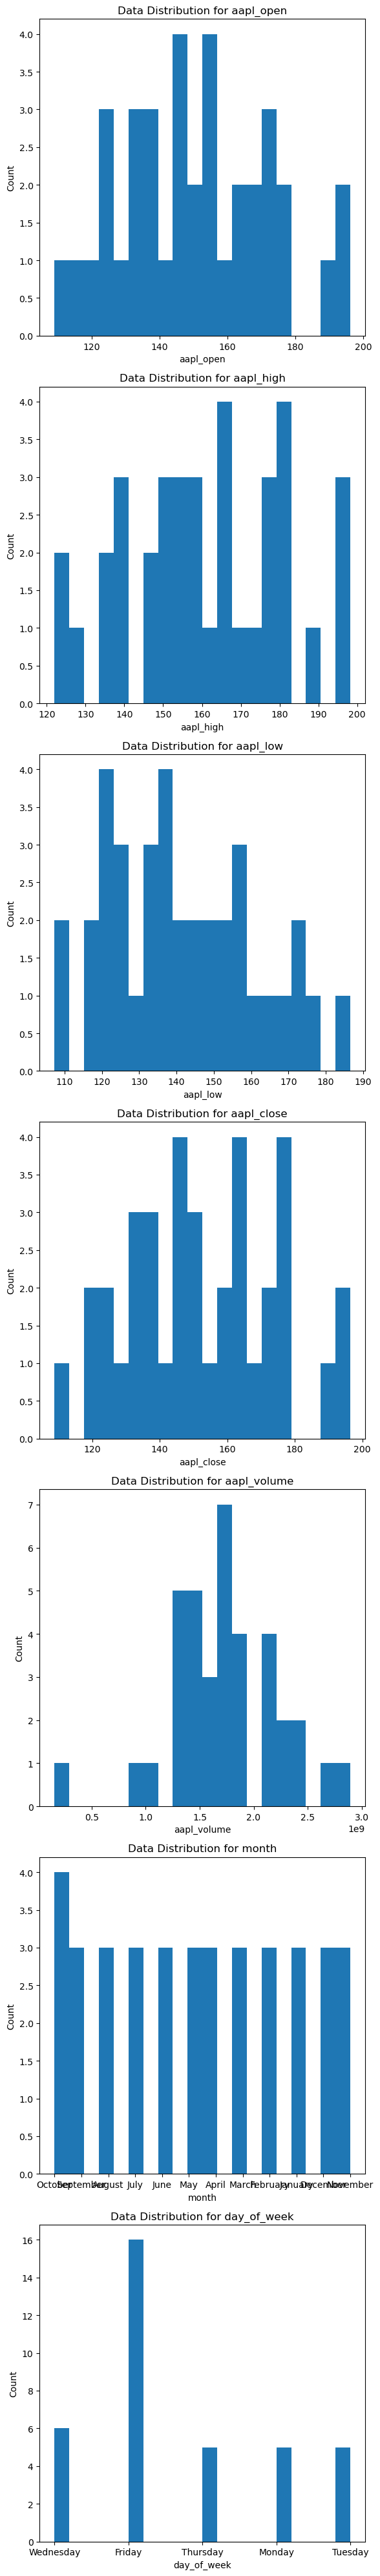

In [57]:
# Select a subset of columns for visualization
selected_columns = ['aapl_open','aapl_high','aapl_low',
                    'aapl_close', 'aapl_volume', 'month',
                    'day_of_week']

# Create subplots for each column
fig, axes = plt.subplots(nrows=len(selected_columns), figsize=(6, 40))

for i, column in enumerate(selected_columns):
    axes[i].hist(aapl_df[column], bins=20)  # You can adjust the number of bins as needed
    axes[i].set_title(f'Data Distribution for {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

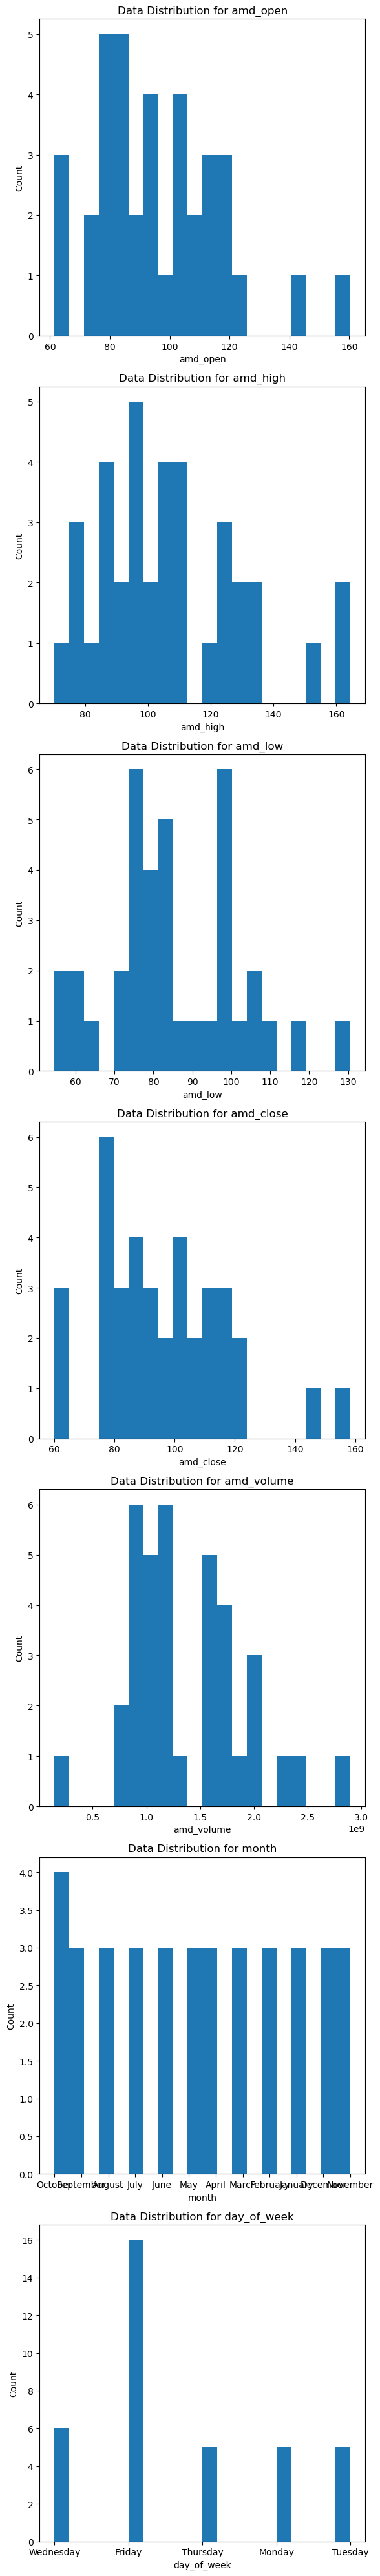

In [58]:
# Select a subset of columns for visualization
selected_columns = ['amd_open','amd_high','amd_low',
                    'amd_close', 'amd_volume', 'month',
                    'day_of_week']

# Create subplots for each column
fig, axes = plt.subplots(nrows=len(selected_columns), figsize=(6, 40))

for i, column in enumerate(selected_columns):
    axes[i].hist(amd_df[column], bins=20)  # You can adjust the number of bins as needed
    axes[i].set_title(f'Data Distribution for {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## I noted that daily volume over 20 years between each stock varies greatly and the data remained normal, but the categorical is unifrom due to it being a datetime value

## I had to back and adjust to return only 2 years of data

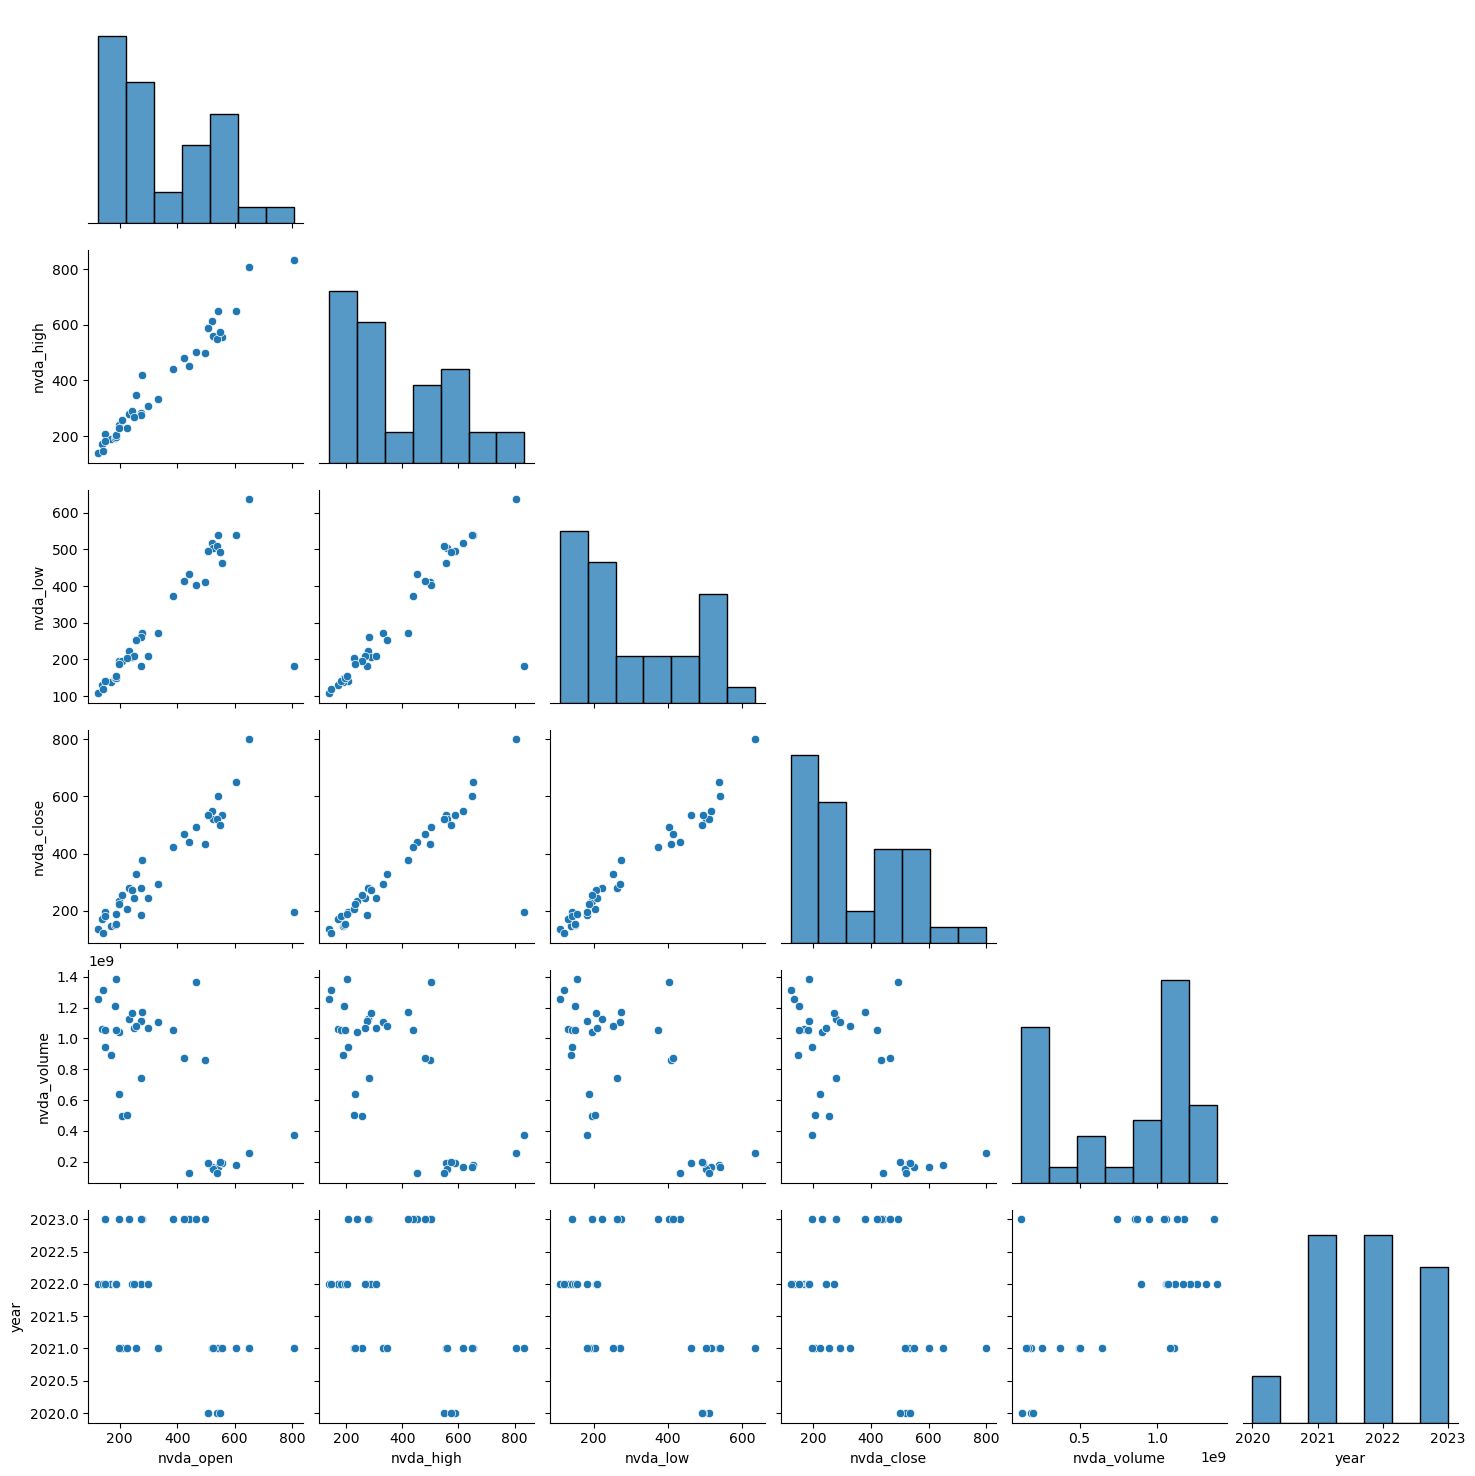

In [59]:
sns.pairplot(nvda_df, corner=True)

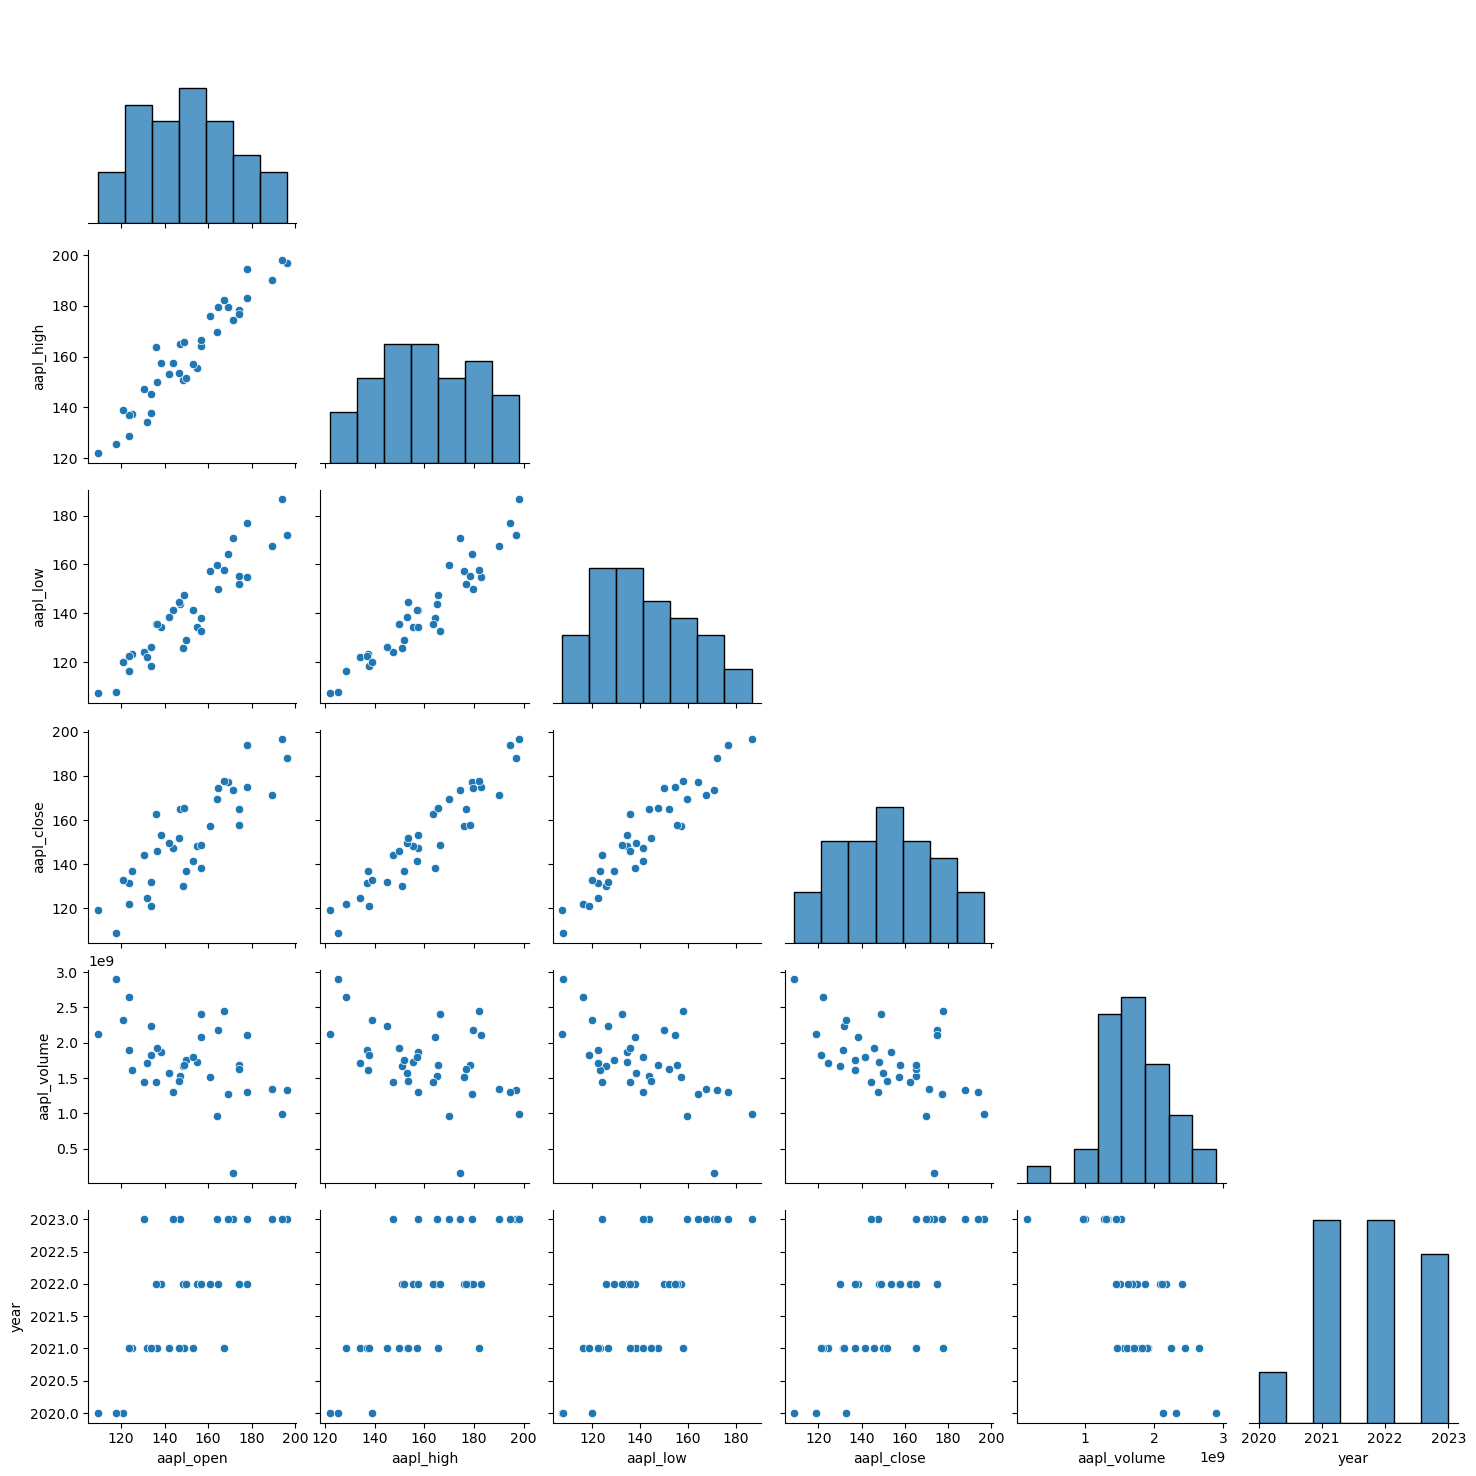

In [60]:
sns.pairplot(aapl_df, corner=True)

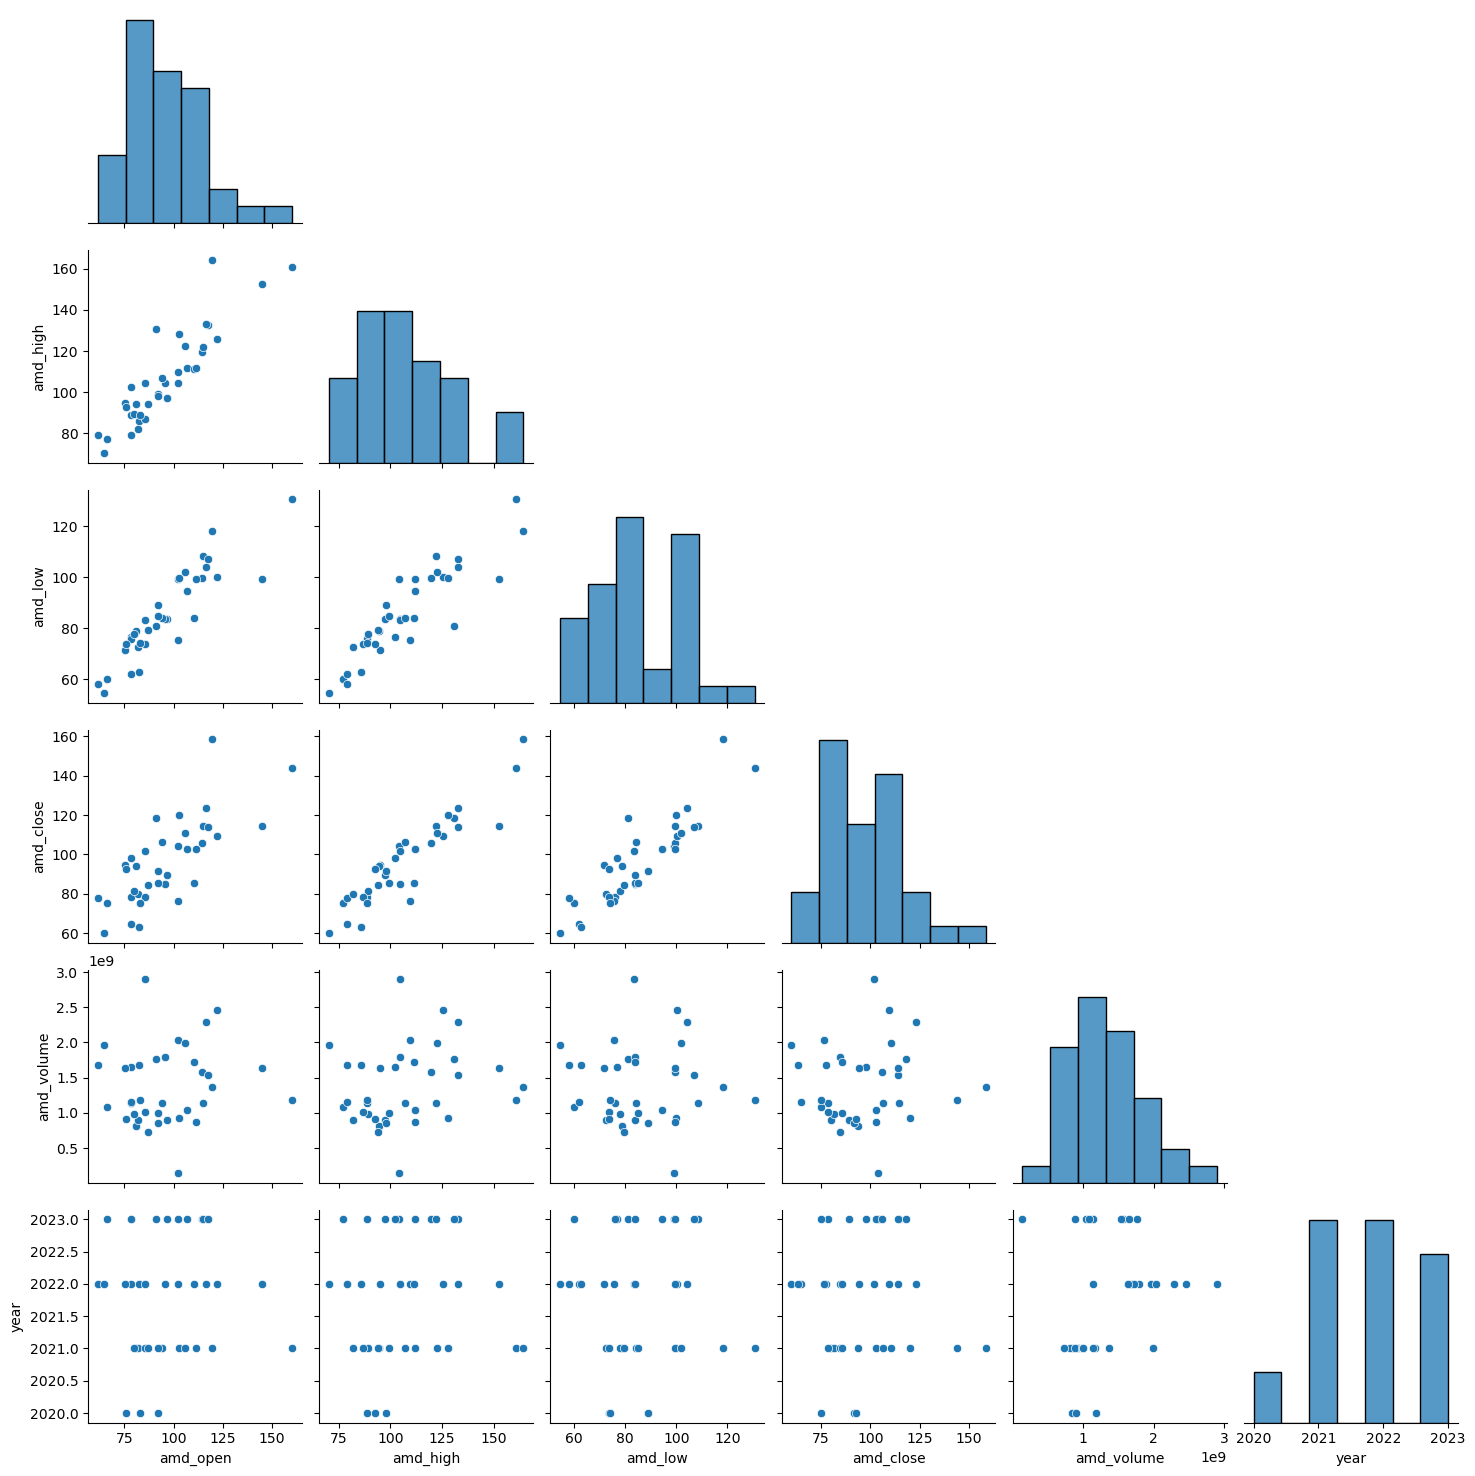

In [61]:
sns.pairplot(amd_df, corner=True)

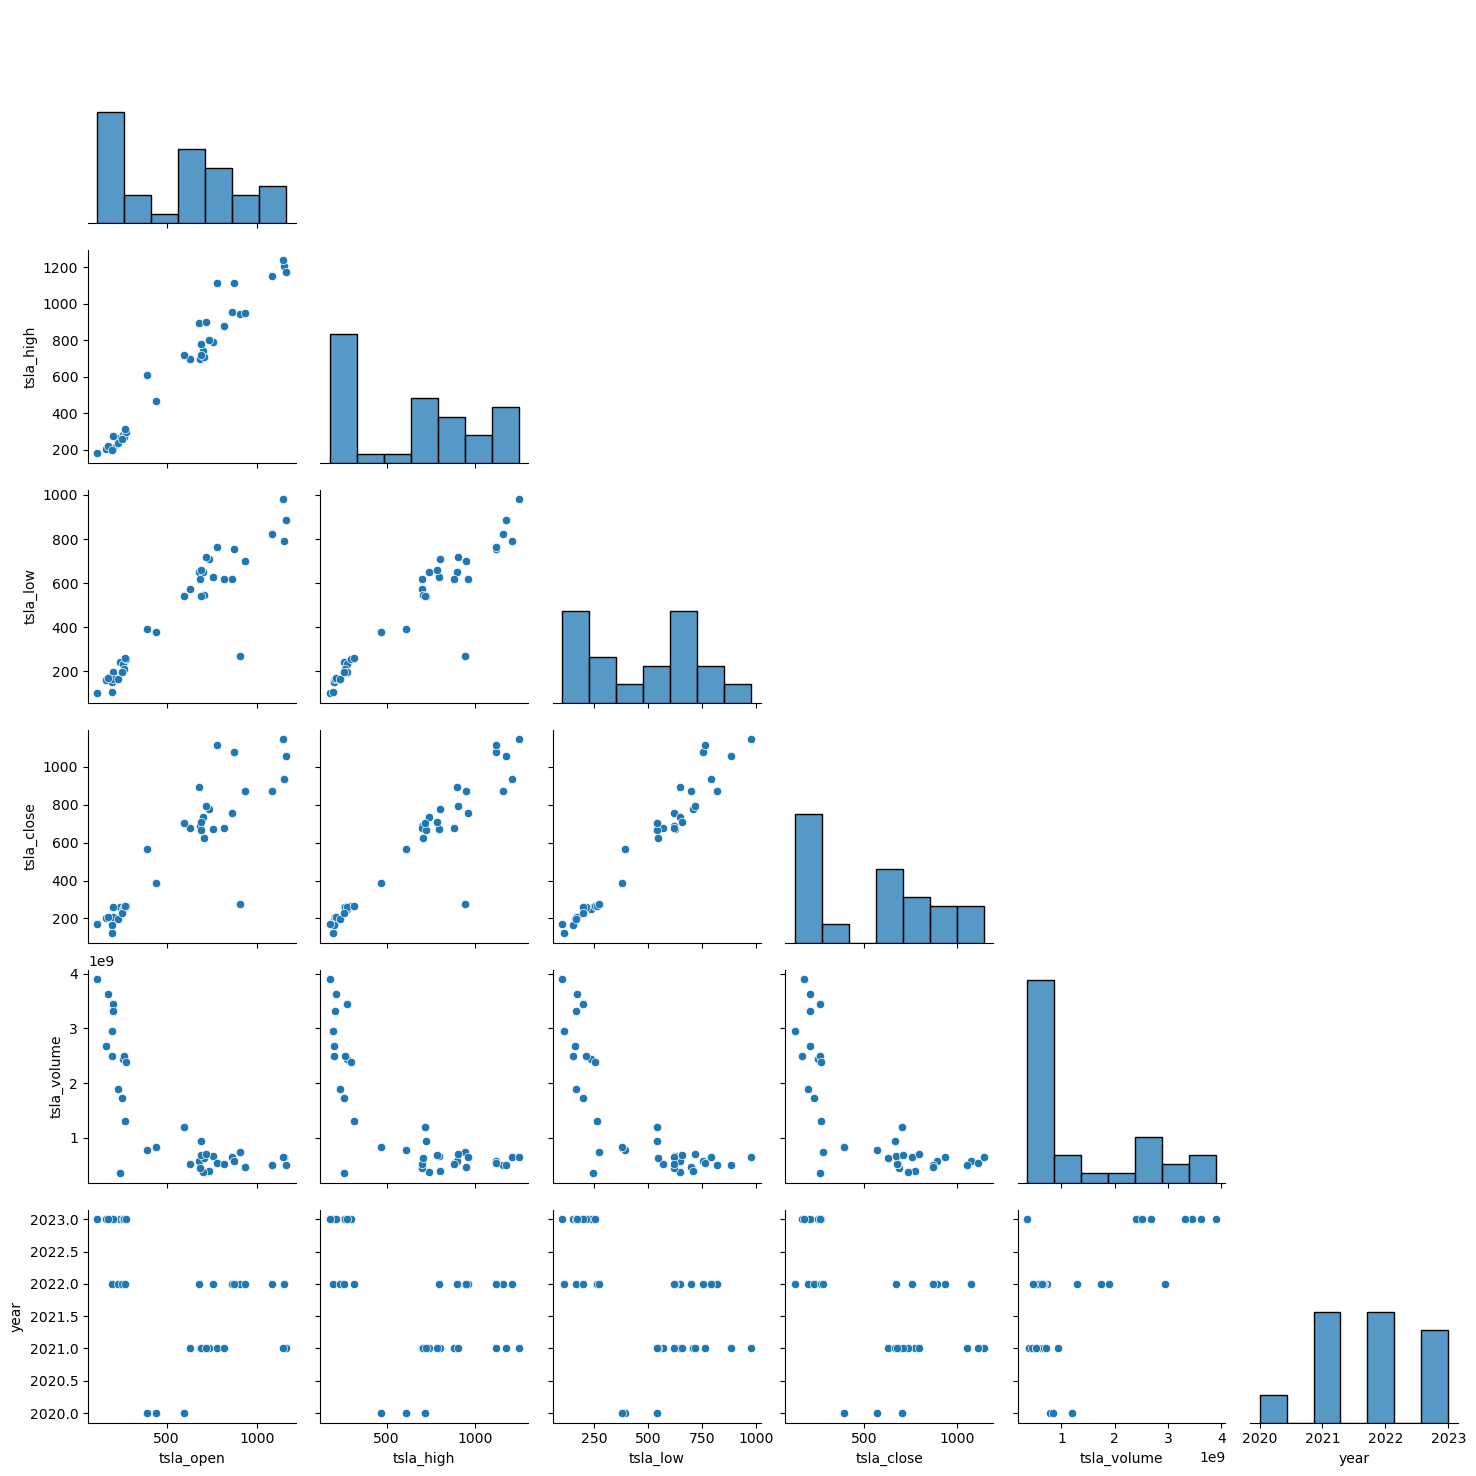

In [62]:
sns.pairplot(tsla_df, corner=True)

## The pair plots display target and other features to be very messy  
  
## I did notice open, high, low, and close features when plotted together seem to be very correlated and are really good features to possibly use!

## additionally i can tell from the hist plots on the end that the data is massive and I may have to scale volume also they are right skewed and right tails which is something to note.

-----------

# NVDA Train set | Explore & Stats test

In [63]:
nvda_train, nvda_val, nvda_test = p.train_val_test(nvda_df)

## Question 1

### Does NVDA stock volume have a correlation with it's daily closing price?  


> **Null Hypothesis($H0$):** volume of stock **does have a significant correlation** with close price of NVDA stock.  
>
> **Alternative Hypothesis($Ha$):** volume of stock **does NOT have a significant correlation** with close price of NVDA stock.  

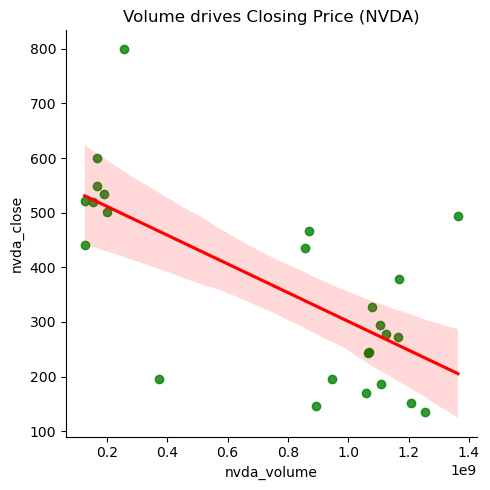

In [64]:
sns.lmplot(data=nvda_train, x='nvda_volume', y='nvda_close', scatter_kws={'color': 'green'}, line_kws={'color': 'red'}).set(title='Volume drives Closing Price (NVDA)')
plt.tight_layout()
plt.show()

In [65]:
correlation_coefficient, p_value, conclusion = e.evaluate_correlation(nvda_train.nvda_volume, nvda_train.nvda_close, method="Pearson")
print(f'{conclusion}\n\np-value: {p_value}')

Reject the null hypothesis.

There is a significant linear correlation between nvda_volume and nvda_close.

p-value: 0.0002035580463592994


## **Takeaway:**  

* ### There seems to be a correlation around 580 closing price for NVDA, but does not correlate past that value and most of it is concentrated when teh volume is lower. Furthermore, we can concretely confirm that they are correlated after running a pearson test

## Question 2

### Is there a significant correlation between the month in which NVDA stock was traded and its closing price?

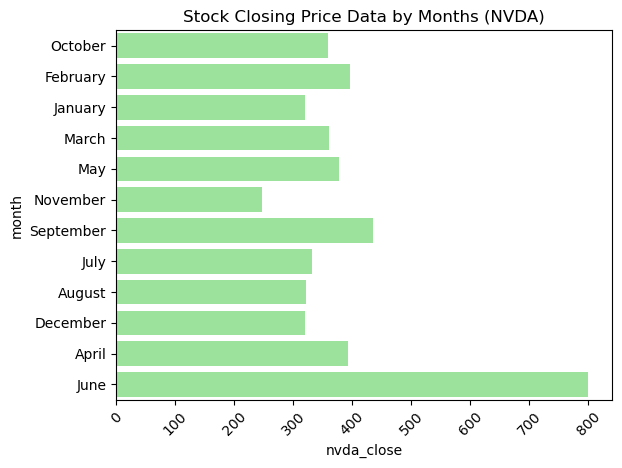

In [66]:
plt.figure()
sns.barplot(data=nvda_train, x='nvda_close', y='month', color='lightgreen', errorbar=None).set(title='Stock Closing Price Data by Months (NVDA)')
plt.xticks(rotation=45)
plt.show()

## **Takeaway:**  

* ### Here we can see over the 20 year plus span taht the data shows the month of june being the month that has the highest closing price. we can take away that there is a relationship between these features and month may prove useful for predicting close_price

## **Question 3**

### Does NVDA daily high stock price have a correlation with open stock price?**  

>**Null Hypothesis($H0$):** There is **a significant correlation** between the high price and the open price of NVDA stock.  
>
>**Alternative Hypothesis($Ha$):** There **is no significant correlation** between the high price and the open price of NVDA stock. 

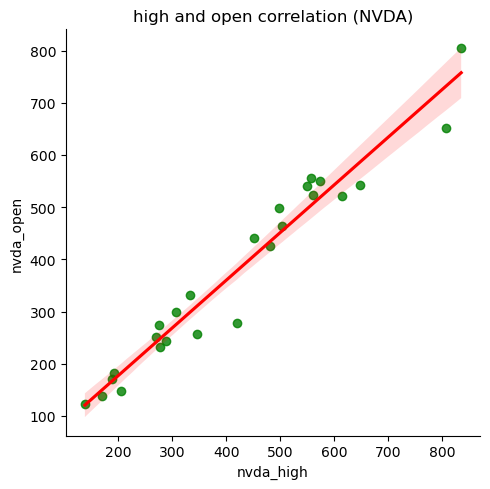

In [67]:
sns.lmplot(data=nvda_train, x='nvda_high', y='nvda_open', scatter_kws={'color': 'green'}, line_kws={'color': 'red'}).set(title='high and open correlation (NVDA)')
plt.tight_layout()
plt.show()

In [68]:
correlation_coefficient, p_value, conclusion = e.evaluate_correlation(nvda_train.nvda_high, nvda_train.nvda_open, method="Pearson")
print(f'{conclusion}\n\np-value: {p_value}')

Reject the null hypothesis.

There is a significant linear correlation between nvda_high and nvda_open.

p-value: 1.3001487770132288e-16


## **Takeaway:**  

* ### We can see visually before running a stats test that these two features are very correlated so these will be super helpful in prediction.

## Question 4

### Is there a significant correlation between the month in which NVDA stock was traded and its closing price?

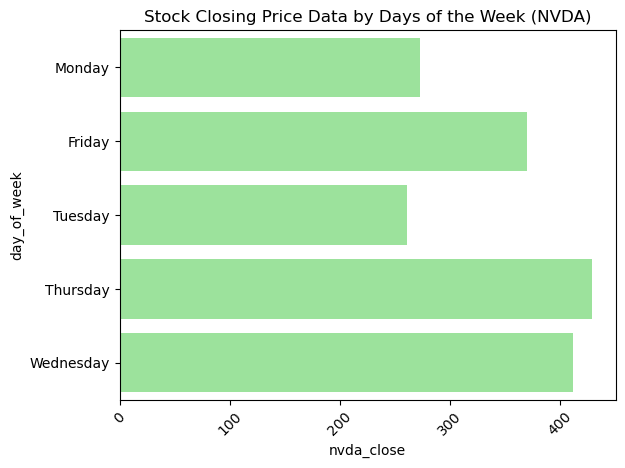

In [69]:
plt.figure()
sns.barplot(data=nvda_train, x='nvda_close', y='day_of_week', color='lightgreen', errorbar=None).set(title='Stock Closing Price Data by Days of the Week (NVDA)')
plt.xticks(rotation=45)
plt.show()

## **Takeaway:**  

* ### This visual can tell us that the data is very uniform, but we can discern the tiny differences of close price for each day which means its pretty average daily

 # ================================================

# AAPL Train set | Explore & Stats test

In [70]:
aapl_train, aapl_val, aapl_test = p.train_val_test(aapl_df)

## Question 1

### Does Apple stock volume have a correlation with it's daily closing price?  


> **Null Hypothesis($H0$):** volume of stock **does have a significant correlation** with close price of AAPL stock.  
>
> **Alternative Hypothesis($Ha$):** volume of stock **does NOT have a significant correlation** with close price of AAPL stock.  

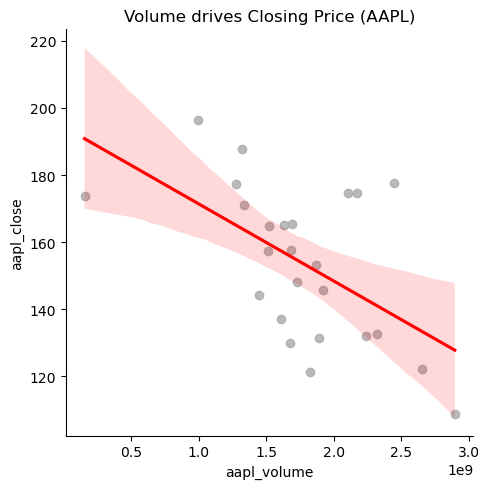

In [71]:
sns.lmplot(data=aapl_train, x='aapl_volume', y='aapl_close', scatter_kws={'color': 'darkgrey'}, line_kws={'color': 'red'}).set(title='Volume drives Closing Price (AAPL)')
plt.tight_layout()
plt.show()

In [72]:
correlation_coefficient, p_value, conclusion = e.evaluate_correlation(aapl_train.aapl_volume, aapl_train.aapl_close, method="Pearson")
print(f'{conclusion}\n\np-value: {p_value}')

Reject the null hypothesis.

There is a significant linear correlation between aapl_volume and aapl_close.

p-value: 0.0036030597699888006


## **Takeaway:**  

* ### There seems to be a correlation for the apple stock volume and close price, but the line of regression appear to have a negeative slope, after conducting out stats test, it tells us that it is correlated, but this proves to be a false positive.

## Question 2

### Is there a significant correlation between the month in which Apple stock was traded and its closing price?

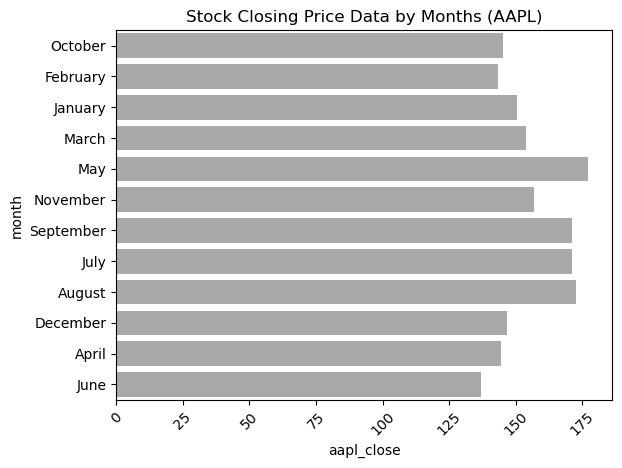

In [73]:
plt.figure()
sns.barplot(data=aapl_train, x='aapl_close', y='month', color='darkgrey', errorbar=None).set(title='Stock Closing Price Data by Months (AAPL)')
plt.xticks(rotation=45)
plt.show()

## **Takeaway:**  

* ### Here we can see over the 20 year plus span that the data shows the month of may being the month that has the highest closing price. we can take away that there is a relationship between these features and month may prove useful for predicting close_price. The data is very uniform

## **Question 3**

### Does Apple daily high stock price have a correlation with open stock price?**  

**Null Hypothesis($H0$):** There is **a significant correlation** between the high price and the open price of AAPL stock.  

**Alternative Hypothesis($Ha$):** There **is no significant correlation** between the high price and the open price of AAPL stock. 

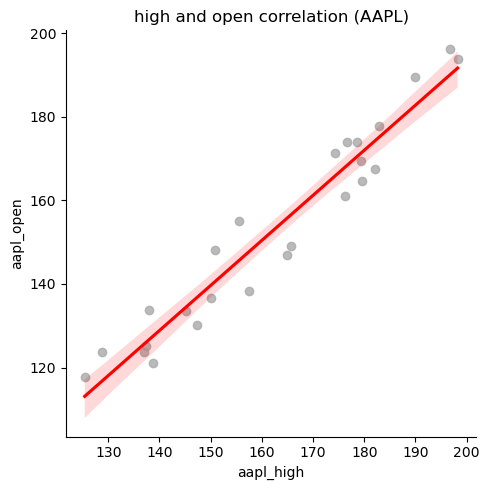

In [74]:
sns.lmplot(data=aapl_train, x='aapl_high', y='aapl_open', scatter_kws={'color': 'darkgrey'}, line_kws={'color': 'red'}).set(title='high and open correlation (AAPL)')
plt.tight_layout()
plt.show()

In [75]:
correlation_coefficient, p_value, conclusion = e.evaluate_correlation(aapl_train.aapl_high, aapl_train.aapl_open, method="Pearson")
print(f'{conclusion}\n\np-value: {p_value}')

Reject the null hypothesis.

There is a significant linear correlation between aapl_high and aapl_open.

p-value: 3.961283788001907e-15


## **Takeaway:**  

* ### We can see visually before running a stats test that these two features are very correlated so these will be super helpful in prediction.

## Question 4

### Is there a significant correlation between the month in which NVDA stock was traded and its closing price?

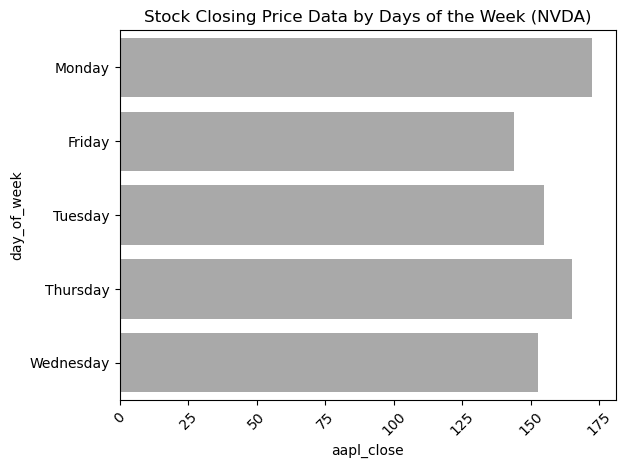

In [76]:
plt.figure()
sns.barplot(data=aapl_train, x='aapl_close', y='day_of_week', color='darkgrey', errorbar=None).set(title='Stock Closing Price Data by Days of the Week (NVDA)')
plt.xticks(rotation=45)
plt.show()

## **Takeaway:**  

* ### This visual can tell us that the data is very uniform, but we can discern the tiny differences of close price for each day which means its pretty average daily

## Now that we explored without time, I will conduct exploration with time

 # ================================================

# AMD Train set | Explore & Stats test

In [77]:
amd_train, amd_val, amd_test = p.train_val_test(amd_df)

## Question 1

### Does AMD stock volume have a correlation with it's daily closing price?  


> **Null Hypothesis($H0$):** volume of stock **does have a significant correlation** with close price of AMD stock.  
>
> **Alternative Hypothesis($Ha$):** volume of stock **does NOT have a significant correlation** with close price of AMD stock.  

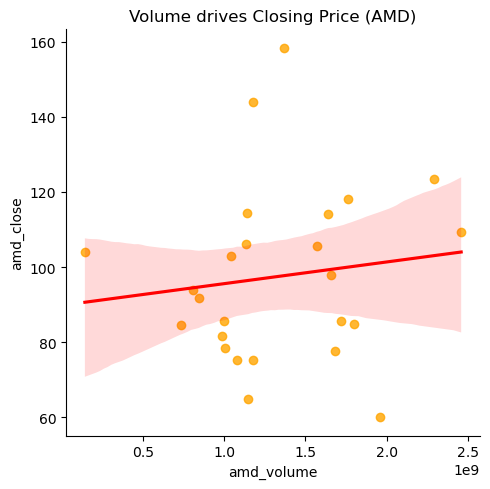

In [78]:
sns.lmplot(data=amd_train, x='amd_volume', y='amd_close', scatter_kws={'color': 'orange'}, line_kws={'color': 'red'}).set(title='Volume drives Closing Price (AMD)')
plt.tight_layout()
plt.show()

In [79]:
correlation_coefficient, p_value, conclusion = e.evaluate_correlation(amd_train.amd_volume, amd_train.amd_close, method="Pearson")
print(f'{conclusion}\n\np-value: {p_value}')

Fail to reject the null hypothesis.

There is no significant linear correlation between amd_volume and amd_close.

p-value: 0.5404025198645445


## **Takeaway:**  

* ### There seems to be a correlation for the AMD stock volume and close price. After conducting out stats test we can furtehr confirm this will be a useful feature in our predictions.

## Question 2

### Is there a significant correlation between the month in which AMD stock was traded and its closing price?

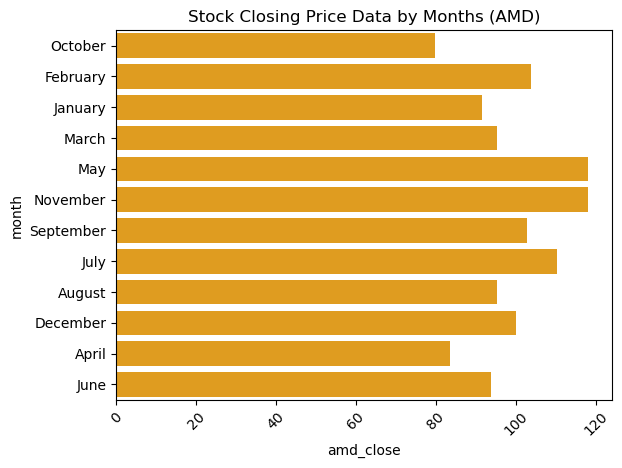

In [80]:
plt.figure()
sns.barplot(data=amd_train, x='amd_close', y='month', color='orange', errorbar=None).set(title='Stock Closing Price Data by Months (AMD)')
plt.xticks(rotation=45)
plt.show()

## **Takeaway:**  

* ### Here we can see over the 20 year plus span that the data shows the month of September being the month that has the highest closing price. we can take away that there is a relationship between these features and month may prove useful for predicting close_price. The data is normal, and les uniform unlike the other stocks companies

## **Question 3**

### Does AMD daily high stock price have a correlation with open stock price?

**Null Hypothesis($H0$):** There is **a significant correlation** between the high price and the open price of AMD stock.  

**Alternative Hypothesis($Ha$):** There **is no significant correlation** between the high price and the open price of AMD stock. 

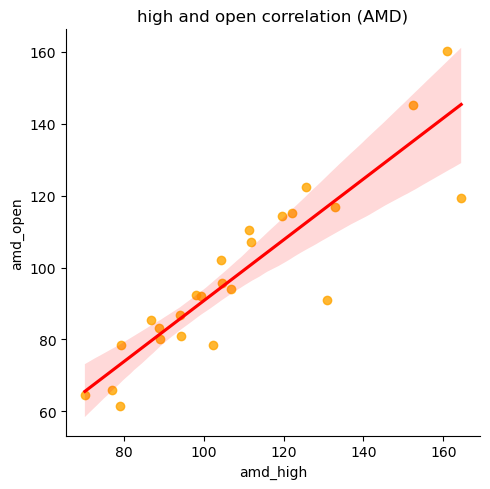

In [81]:
sns.lmplot(data=amd_train, x='amd_high', y='amd_open', scatter_kws={'color': 'orange'}, line_kws={'color': 'red'}).set(title='high and open correlation (AMD)')
plt.tight_layout()
plt.show()

In [82]:
correlation_coefficient, p_value, conclusion = e.evaluate_correlation(amd_train.amd_high, amd_train.amd_open, method="Pearson")
print(f'{conclusion}\n\np-value: {p_value}')

Reject the null hypothesis.

There is a significant linear correlation between amd_high and amd_open.

p-value: 9.027369934335469e-10


## **Takeaway:**  

* ### We can see visually before running a stats test that these two features are very correlated so these will be super helpful in prediction.

## Question 4

### Is there a significant correlation between the month in which AMD stock was traded and its closing price?

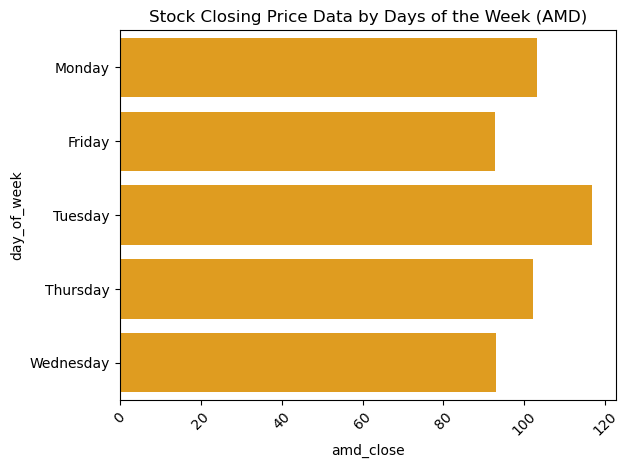

In [83]:
plt.figure()
sns.barplot(data=amd_train, x='amd_close', y='day_of_week', color='orange', errorbar=None).set(title='Stock Closing Price Data by Days of the Week (AMD)')
plt.xticks(rotation=45)
plt.show()

## **Takeaway:**  

* ### This visual can tell us that the data is very uniform, but we can discern the tiny differences of close price for each day which means its pretty average daily

# TSLA Train set | Explore & Stats test

In [84]:
tsla_train, tsla_val, tsla_test = p.train_val_test(tsla_df)

## Question 1

### Does AMD stock volume have a correlation with it's daily closing price?  


> **Null Hypothesis($H0$):** volume of stock **does have a significant correlation** with close price of AMD stock.  
>
> **Alternative Hypothesis($Ha$):** volume of stock **does NOT have a significant correlation** with close price of AMD stock.  

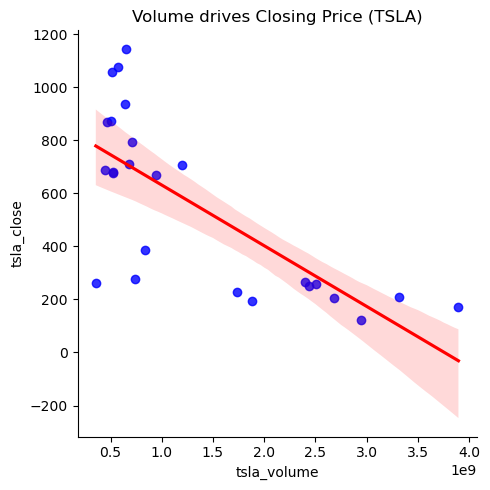

In [85]:
sns.lmplot(data=tsla_train, x='tsla_volume', y='tsla_close', scatter_kws={'color': 'blue'}, line_kws={'color': 'red'}).set(title='Volume drives Closing Price (TSLA)')
plt.tight_layout()
plt.show()

In [86]:
correlation_coefficient, p_value, conclusion = e.evaluate_correlation(tsla_train.tsla_volume, tsla_train.tsla_close, method="Pearson")
print(f'{conclusion}\n\np-value: {p_value}')

Reject the null hypothesis.

There is a significant linear correlation between tsla_volume and tsla_close.

p-value: 2.852074682290362e-05


## **Takeaway:**  

* ### There seems to be a correlation for the AMD stock volume and close price. After conducting out stats test we can furtehr confirm this will be a useful feature in our predictions.

## Question 2

### Is there a significant correlation between the month in which AMD stock was traded and its closing price?

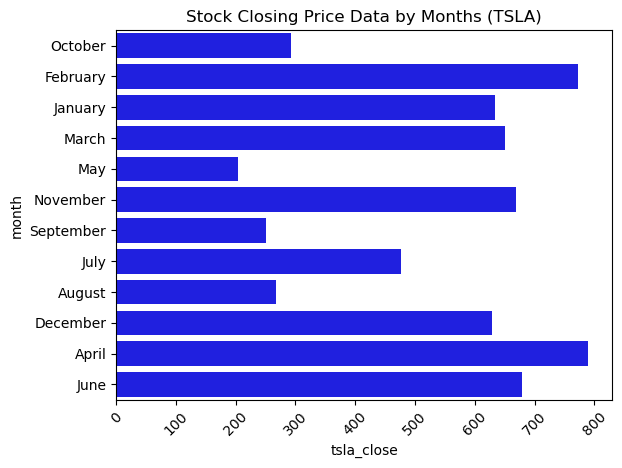

In [87]:
plt.figure()
sns.barplot(data=tsla_train, x='tsla_close', y='month', color='blue', errorbar=None).set(title='Stock Closing Price Data by Months (TSLA)')
plt.xticks(rotation=45)
plt.show()

## **Takeaway:**  

* ### Here we can see over the 20 year plus span that the data shows the month of September being the month that has the highest closing price. we can take away that there is a relationship between these features and month may prove useful for predicting close_price. The data is normal, and les uniform unlike the other stocks companies

## **Question 3**

### Does AMD daily high stock price have a correlation with open stock price?

**Null Hypothesis($H0$):** There is **a significant correlation** between the high price and the open price of AMD stock.  

**Alternative Hypothesis($Ha$):** There **is no significant correlation** between the high price and the open price of AMD stock. 

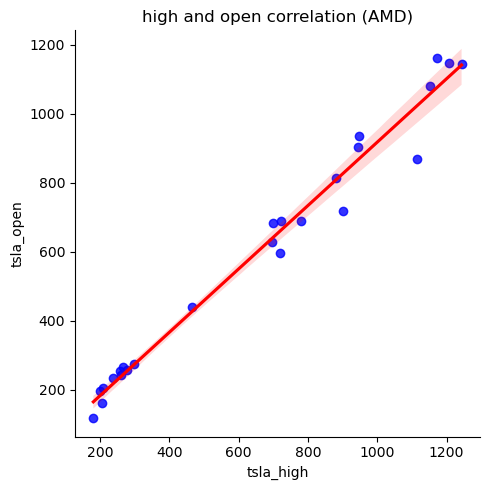

In [88]:
sns.lmplot(data=tsla_train, x='tsla_high', y='tsla_open', scatter_kws={'color': 'blue'}, line_kws={'color': 'red'}).set(title='high and open correlation (AMD)')
plt.tight_layout()
plt.show()

In [89]:
correlation_coefficient, p_value, conclusion = e.evaluate_correlation(tsla_train.tsla_high, tsla_train.tsla_open, method="Pearson")
print(f'{conclusion}\n\np-value: {p_value}')

Reject the null hypothesis.

There is a significant linear correlation between tsla_high and tsla_open.

p-value: 7.224353132581041e-21


## **Takeaway:**  

* ### We can see visually before running a stats test that these two features are very correlated so these will be super helpful in prediction.

## Question 4

### Is there a significant correlation between the month in which AMD stock was traded and its closing price?

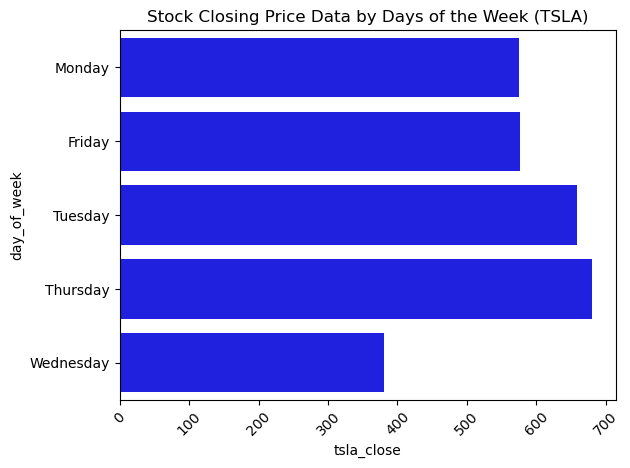

In [90]:
plt.figure()
sns.barplot(data=tsla_train, x='tsla_close', y='day_of_week', color='blue', errorbar=None).set(title='Stock Closing Price Data by Days of the Week (TSLA)')
plt.xticks(rotation=45)
plt.show()

## **Takeaway:**  

* ### This visual can tell us that the data is very uniform, but we can discern the tiny differences of close price for each day which means its pretty average daily

 ## I have gone through all of the companies stocks i want to explore and determined that each stock may have different feature weights. The stats test between continous features tells us that there is some differences in each stock and it's historical data, but have a correlation of some kind.

## At this point i will begin to model complete my assessment of each stock I selected and compare the drawn conclusions and the insights gained in predicting each stock closing price.

# Modeling

### below I am calling a function that wrangles the data and returns each dataframe to model. I am also splitting and scaling the dataframe in order to run model functions on the dataframes to retrieve model performance an predictions using regression modeling for the stocks data.

In [91]:
nvda_df, aapl_df, amd_df, tsla_df, vvos_df = w.wrangle_stock_data()

In [92]:
nvda_train, nvda_val, nvda_test = w.split_and_scale_data(nvda_df)
aapl_train, aapl_val, aapl_test = w.split_and_scale_data(aapl_df)
amd_train, amd_val, amd_test = w.split_and_scale_data(amd_df)
tsla_train, tsla_val, tsla_test = w.split_and_scale_data(tsla_df)
vvos_train, vvos_val, vvos_test = w.split_and_scale_data(vvos_df)

In [93]:
nvda_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 25 entries, 2020-12-31 to 2021-06-30
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   nvda_open         25 non-null     float64
 1   nvda_high         25 non-null     float64
 2   nvda_low          25 non-null     float64
 3   nvda_close        25 non-null     float64
 4   nvda_volume       25 non-null     float64
 5   month             25 non-null     object 
 6   day_of_week       25 non-null     object 
 7   year              25 non-null     int32  
 8   next_month_close  25 non-null     float64
dtypes: float64(6), int32(1), object(2)
memory usage: 1.9+ KB


In [94]:
nvda_train.head()

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume,month,day_of_week,year,next_month_close
2020-12-31,0.602168,0.570314,0.752052,0.575050,0.001148,December,Thursday,2020,0.603025
2023-10-04,0.453133,0.423702,0.597943,0.449982,0.000000,October,Wednesday,2023,0.451070
2023-06-30,0.370046,0.405883,0.481671,0.423390,0.748726,June,Friday,2023,0.365898
2021-05-28,0.700100,0.723465,0.806996,0.770139,0.040234,May,Friday,2021,0.699728
2022-07-29,0.016315,0.018736,0.021695,0.054269,0.751825,July,Friday,2022,0.024988


In [95]:
nvda_val.head()

,nvda_open,nvda_high,nvda_low,nvda_close,nvda_volume,month,day_of_week,year,next_month_close
2023-02-28,0.088170,0.103606,0.131374,0.131537,0.737899,February,Tuesday,2023,0.090809
2022-06-30,0.073670,0.039412,0.037626,0.008334,0.751050,June,Thursday,2022,0.077804
2022-10-31,-0.021953,-0.047337,-0.042304,-0.017081,0.912329,October,Monday,2022,-0.020417
2021-04-30,0.606967,0.719657,0.811122,0.694599,0.033451,April,Friday,2021,0.599823
2022-01-31,0.239980,0.206204,0.156583,0.150957,0.760682,January,Monday,2022,0.239261


## Checking all subset shapes to ensure the data was split correctly

In [96]:
nvda_train.shape, nvda_val.shape, nvda_val.shape

((25, 9), (5, 9), (5, 9))

In [97]:
aapl_train.shape, aapl_val.shape, aapl_val.shape

((25, 9), (5, 9), (5, 9))

In [98]:
amd_train.shape, amd_val.shape, amd_val.shape

((25, 9), (5, 9), (5, 9))

In [99]:
tsla_train.shape, tsla_val.shape, tsla_val.shape

((25, 9), (5, 9), (5, 9))

In [100]:
vvos_train.shape, vvos_val.shape, vvos_val.shape

((23, 9), (5, 9), (5, 9))

## Now we have to do an xy split in order for us to have useable subset for regression modeling. We will aslo look at the baselines before implementing models

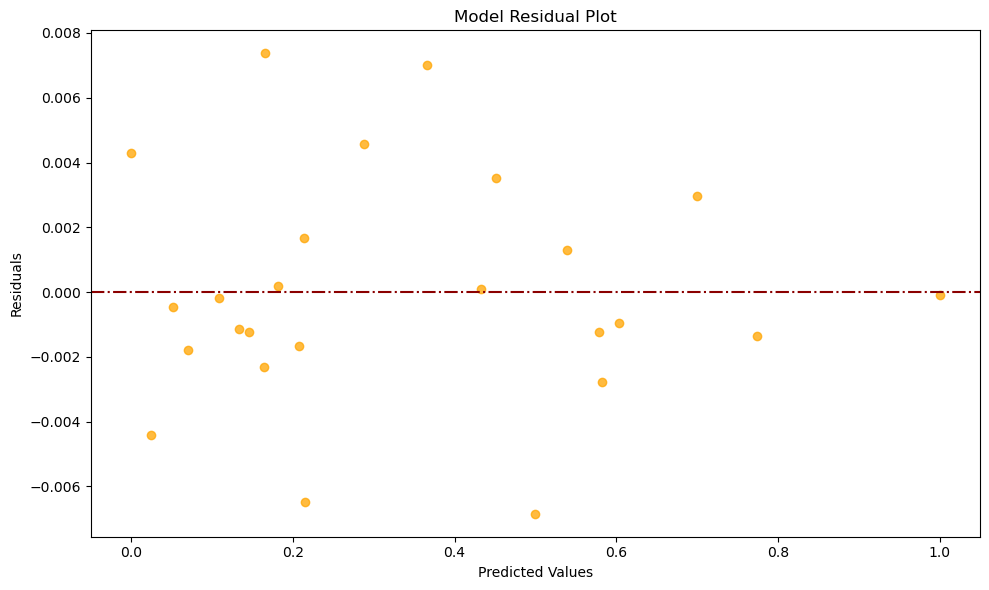


-------------------------------------
Model RMSE: 0.00
Model R-squared: 1.00

-------------------------------------
Baseline RMSE: 0.29
baseline R-squared: -0.23

-------------------------------------


In [101]:
m.lin_reg_baseline_model(nvda_train, 'next_month_close')

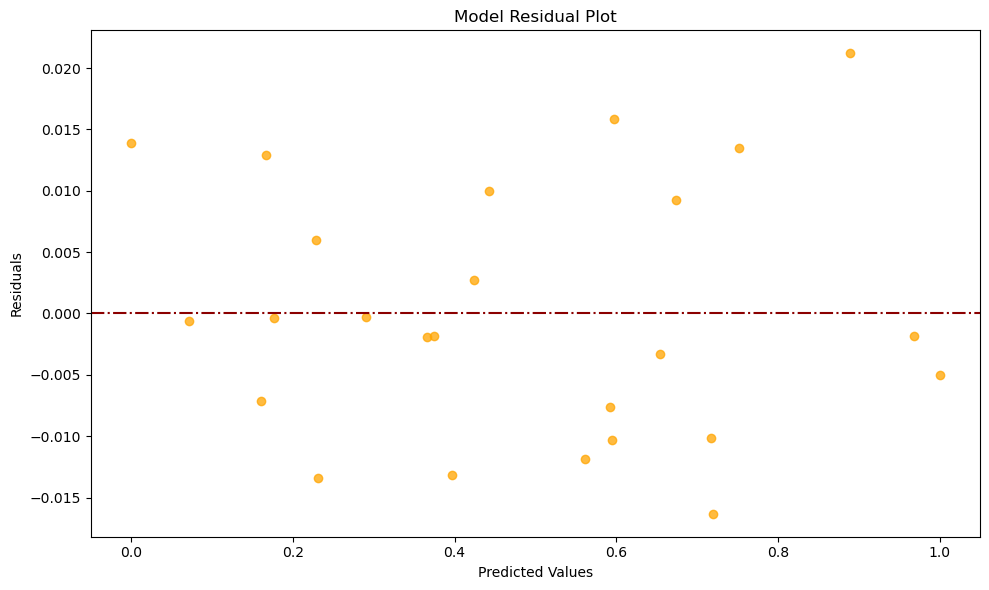


-------------------------------------
Model RMSE: 0.01
Model R-squared: 1.00

-------------------------------------
Baseline RMSE: 0.28
baseline R-squared: -0.02

-------------------------------------


In [102]:
m.lin_reg_baseline_model(aapl_train, 'next_month_close')

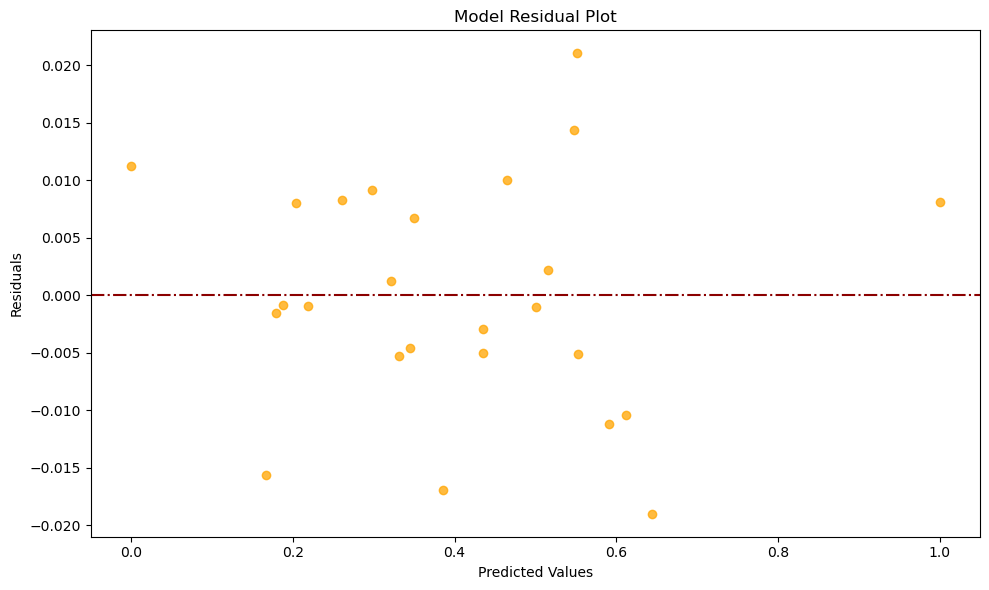


-------------------------------------
Model RMSE: 0.01
Model R-squared: 1.00

-------------------------------------
Baseline RMSE: 0.20
baseline R-squared: -0.01

-------------------------------------


In [103]:
m.lin_reg_baseline_model(amd_train, 'next_month_close')

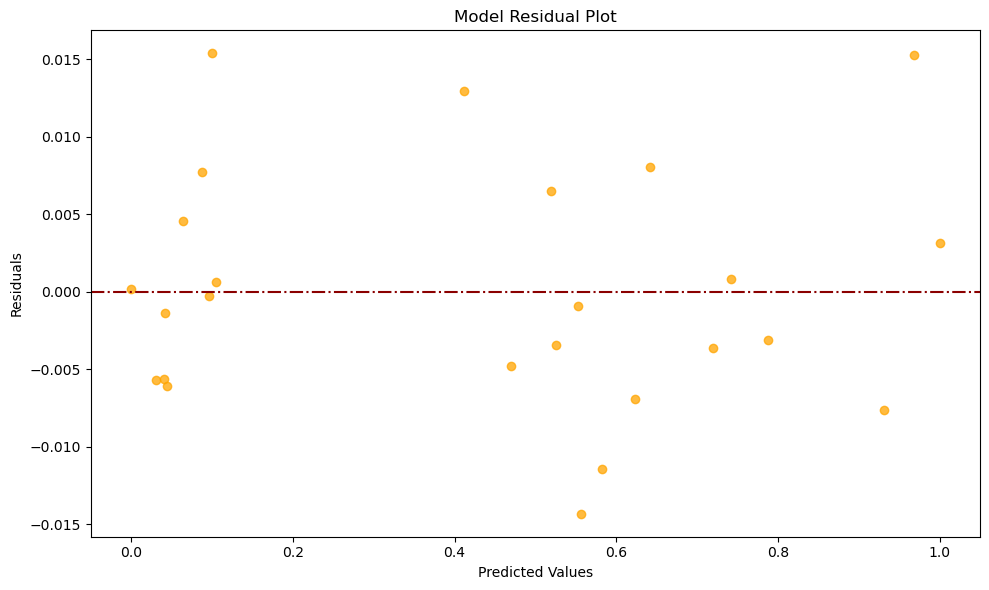


-------------------------------------
Model RMSE: 0.01
Model R-squared: 1.00

-------------------------------------
Baseline RMSE: 0.34
baseline R-squared: -0.08

-------------------------------------


In [104]:
m.lin_reg_baseline_model(tsla_train, 'next_month_close')

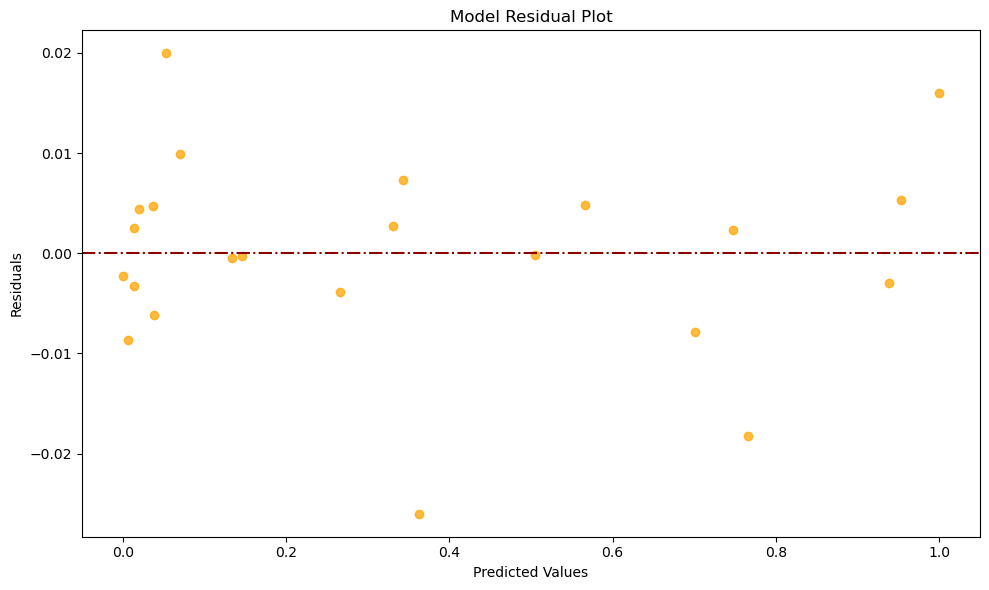


-------------------------------------
Model RMSE: 0.01
Model R-squared: 1.00

-------------------------------------
Baseline RMSE: 0.35
baseline R-squared: -0.06

-------------------------------------


In [105]:
m.lin_reg_baseline_model(vvos_train, 'next_month_close')

## After applying linear regression on the data We can see that the baseline model is pretty good for month to month and linear regression improved it

## Now I will implement linear regression and rf regression on the TSLA and VVOS stocks

In [106]:
from evaluate import plot_residuals, regression_errors, baseline_mean_errors, better_than_baseline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from math import sqrt

In [109]:
tsla_train = tsla_train.drop(columns=(['month', 'day_of_week']))
tsla_val = tsla_val.drop(columns=(['month', 'day_of_week']))
tsla_test = tsla_test.drop(columns=(['month', 'day_of_week']))

In [111]:
# xy_split function to create usable subsets; reusable.
X_train, y_train = m.xy_split(tsla_train, 'next_month_close')
X_val, y_val = m.xy_split(tsla_val, 'next_month_close')
X_test, y_test = m.xy_split(tsla_test, 'next_month_close')

In [112]:
def model_1(X_train, y_train, X_val, y_val):
    # Initialize the RandomForestRegressor
    rfr = RandomForestRegressor()
    
    # Train the model on the training data
    rfr.fit(X_train, y_train)
    
    # Make predictions on training and validation sets
    train_preds = rfr.predict(X_train)
    val_preds = rfr.predict(X_val)
    
    # Calculate RMSE for training and validation sets
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    
    # Calculate R-squared (R2) for training and validation sets
    train_r2 = r2_score(y_train, train_preds)
    val_r2 = r2_score(y_val, val_preds)
    
    # Print the metrics
    print(f"\n-------------------------------------")
    print(f"\nTraining RMSE: {train_rmse:.2f}")
    print(f"\n-------------------------------------")
    print(f"\nValidation RMSE: {val_rmse:.2f}")
    print(f"\n-------------------------------------")
    print(f"\nTraining R-squared (R2): {train_r2:.2f}")
    print(f"\n-------------------------------------")
    print(f"\nValidation R-squared (R2): {val_r2:.2f}")

In [113]:
model_1(X_train, y_train, X_val, y_val)


-------------------------------------

Training RMSE: 0.03

-------------------------------------

Validation RMSE: 0.02

-------------------------------------

Training R-squared (R2): 0.99

-------------------------------------

Validation R-squared (R2): 1.00


In [114]:
def model_2(train_df, val_df, target_column):
    """
    Train and evaluate a linear regression baseline model.

    Parameters:
    - train_df (DataFrame): The training dataset.
    - val_df (DataFrame): The validation dataset.
    - target_column (str): The name of the target column.

    Returns:
    - None (prints evaluation metrics).
    """
    # Filter out non-numeric columns (categorical features) in training data
    numeric_cols = train_df.select_dtypes(include=[np.number]).columns
    train_df = train_df[numeric_cols]

    # Filter out non-numeric columns in validation data (keep only those in training data)
    val_df = val_df[numeric_cols]

    # Split training data into X_train (features) and y_train (target)
    X_train = train_df.drop(columns=[target_column])
    y_train = train_df[target_column]

    # Split validation data into X_val (features) and y_val (target)
    X_val = val_df.drop(columns=[target_column])
    y_val = val_df[target_column]

    # Calculate baseline prediction (e.g., using the mean or median of the training target)
    bl = y_train.median()

    # Create DataFrames to work with
    train_preds = pd.DataFrame({'y_actual': y_train, 'y_baseline': bl})
    val_preds = pd.DataFrame({'y_actual': y_val, 'y_baseline': bl})

    # Calculate baseline residuals for both training and validation sets
    train_preds['y_baseline_residuals'] = bl - train_preds['y_actual']
    val_preds['y_baseline_residuals'] = bl - val_preds['y_actual']

    # Initialize and fit a linear regression model
    lm = LinearRegression()
    lm.fit(X_train, y_train)

    # Make predictions with the model for both training and validation sets
    train_preds['y_hat'] = lm.predict(X_train)
    val_preds['y_hat'] = lm.predict(X_val)

    # Calculate model residuals for both training and validation sets
    train_preds['y_hat_residuals'] = train_preds['y_hat'] - train_preds['y_actual']
    val_preds['y_hat_residuals'] = val_preds['y_hat'] - val_preds['y_actual']

    # Calculate and print evaluation metrics for both training and validation sets
    print("\nTraining Set Metrics:")
    evaluate_model(train_preds['y_actual'], train_preds['y_hat'])

    print("\nValidation Set Metrics:")
    evaluate_model(val_preds['y_actual'], val_preds['y_hat'])

def evaluate_model(y_actual, y_pred):
    """
    Evaluate a regression model and print RMSE and R-squared.

    Parameters:
    - y_actual (Series): The actual target values.
    - y_pred (Series): The predicted target values.

    Returns:
    - None (prints evaluation metrics).
    """
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_actual, y_pred)
    print(f"RMSE: {rmse:.2f}")
    print(f"R-squared: {r2:.2f}")

In [115]:
model_2(tsla_train, tsla_val, 'next_month_close')


Training Set Metrics:
RMSE: 0.01
R-squared: 1.00

Validation Set Metrics:
RMSE: 0.04
R-squared: 0.99


In [116]:
def final_model_tsla(X_train, y_train, X_test, y_test):
    # Initialize the RandomForestRegressor
    rfr = RandomForestRegressor()
    
    # Train the model on the training data
    rfr.fit(X_train, y_train)
    
    # Make predictions on training and validation sets
    train_preds = rfr.predict(X_train)
    test_preds = rfr.predict(X_test)
    
    # Calculate RMSE for training and validation sets
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    
    # Calculate R-squared (R2) for training and validation sets
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    
    # Print the metrics
    print(f"\n-------------------------------------")
    print(f"\nTraining RMSE: {train_rmse:.2f}")
    print(f"\n-------------------------------------")
    print(f"\nTest RMSE: {test_rmse:.2f}")
    print(f"\n-------------------------------------")
    print(f"\nTraining R-squared (R2): {train_r2:.2f}")
    print(f"\n-------------------------------------")
    print(f"\nTest R-squared (R2): {test_r2:.2f}")

In [117]:
final_model_tsla(X_train, y_train, X_test, y_test)


-------------------------------------

Training RMSE: 0.04

-------------------------------------

Test RMSE: 0.05

-------------------------------------

Training R-squared (R2): 0.99

-------------------------------------

Test R-squared (R2): 0.96


In [118]:
vvos_train = vvos_train.drop(columns=(['month', 'day_of_week']))
vvos_val = vvos_val.drop(columns=(['month', 'day_of_week']))
vvos_test = vvos_test.drop(columns=(['month', 'day_of_week']))

In [119]:
# xy_split function to create usable subsets; reusable.
X_train, y_train = m.xy_split(vvos_train, 'next_month_close')
X_val, y_val = m.xy_split(vvos_val, 'next_month_close')
X_test, y_test = m.xy_split(vvos_test, 'next_month_close')

In [120]:
def model_1(X_train, y_train, X_val, y_val):
    # Initialize the RandomForestRegressor
    rfr = RandomForestRegressor()
    
    # Train the model on the training data
    rfr.fit(X_train, y_train)
    
    # Make predictions on training and validation sets
    train_preds = rfr.predict(X_train)
    val_preds = rfr.predict(X_val)
    
    # Calculate RMSE for training and validation sets
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    
    # Calculate R-squared (R2) for training and validation sets
    train_r2 = r2_score(y_train, train_preds)
    val_r2 = r2_score(y_val, val_preds)
    
    # Print the metrics
    print(f"\n-------------------------------------")
    print(f"\nTraining RMSE: {train_rmse:.2f}")
    print(f"\n-------------------------------------")
    print(f"\nValidation RMSE: {val_rmse:.2f}")
    print(f"\n-------------------------------------")
    print(f"\nTraining R-squared (R2): {train_r2:.2f}")
    print(f"\n-------------------------------------")
    print(f"\nValidation R-squared (R2): {val_r2:.2f}")

In [121]:
model_1(X_train, y_train, X_val, y_val)


-------------------------------------

Training RMSE: 0.02

-------------------------------------

Validation RMSE: 0.08

-------------------------------------

Training R-squared (R2): 1.00

-------------------------------------

Validation R-squared (R2): 0.77


In [122]:
model_2(vvos_train, vvos_val, 'next_month_close')


Training Set Metrics:
RMSE: 0.01
R-squared: 1.00

Validation Set Metrics:
RMSE: 0.02
R-squared: 0.99


In [123]:
def final_model_vvos(train_df, test_df, target_column):
    """
    Train and evaluate a linear regression baseline model.

    Parameters:
    - train_df (DataFrame): The training dataset.
    - val_df (DataFrame): The validation dataset.
    - target_column (str): The name of the target column.

    Returns:
    - None (prints evaluation metrics).
    """
    # Filter out non-numeric columns (categorical features) in training data
    numeric_cols = train_df.select_dtypes(include=[np.number]).columns
    train_df = train_df[numeric_cols]

    # Filter out non-numeric columns in validation data (keep only those in training data)
    test_df = test_df[numeric_cols]

    # Split training data into X_train (features) and y_train (target)
    X_train = train_df.drop(columns=[target_column])
    y_train = train_df[target_column]

    # Split validation data into X_val (features) and y_val (target)
    X_test = test_df.drop(columns=[target_column])
    y_test = test_df[target_column]

    # Calculate baseline prediction (e.g., using the mean or median of the training target)
    bl = y_train.median()

    # Create DataFrames to work with
    train_preds = pd.DataFrame({'y_actual': y_train, 'y_baseline': bl})
    test_preds = pd.DataFrame({'y_actual': y_test, 'y_baseline': bl})

    # Calculate baseline residuals for both training and validation sets
    train_preds['y_baseline_residuals'] = bl - train_preds['y_actual']
    test_preds['y_baseline_residuals'] = bl - test_preds['y_actual']

    # Initialize and fit a linear regression model
    lm = LinearRegression()
    lm.fit(X_train, y_train)

    # Make predictions with the model for both training and validation sets
    train_preds['y_hat'] = lm.predict(X_train)
    test_preds['y_hat'] = lm.predict(X_test)

    # Calculate model residuals for both training and validation sets
    train_preds['y_hat_residuals'] = train_preds['y_hat'] - train_preds['y_actual']
    test_preds['y_hat_residuals'] = test_preds['y_hat'] - test_preds['y_actual']

    # Calculate and print evaluation metrics for both training and validation sets
    print("\nTraining Set Metrics:")
    evaluate_model(train_preds['y_actual'], train_preds['y_hat'])

    print("\nTest Set Metrics:")
    evaluate_model(test_preds['y_actual'], test_preds['y_hat'])

def evaluate_model(y_actual, y_pred):
    """
    Evaluate a regression model and print RMSE and R-squared.

    Parameters:
    - y_actual (Series): The actual target values.
    - y_pred (Series): The predicted target values.

    Returns:
    - None (prints evaluation metrics).
    """
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_actual, y_pred)
    print(f"RMSE: {rmse:.2f}")
    print(f"R-squared: {r2:.2f}")

In [124]:
final_model_vvos(vvos_train, vvos_test, 'next_month_close')


Training Set Metrics:
RMSE: 0.01
R-squared: 1.00

Test Set Metrics:
RMSE: 0.01
R-squared: 1.00


 ## After modeling I can tell that regression mml techniques are effective when it comes to predicting a closing price for a volatile stock versus a predictable ones like I originally listed. 

## My big takeaway from this project is that you can definitely predict next day or next month closing prices on non-volatile stocks, but not as easy when it comes to predicting for more volatile stocks

## I used the following resource link to retrieve those volatile stocks:
https://www.tradingview.com/markets/stocks-usa/market-movers-most-volatile/